# data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

data = pd.read_csv('data_timur.csv')
data = data.drop(columns=['Unnamed: 0', 'wilayah_bagian'])


In [2]:
data.columns.shape

(46,)

In [3]:
data.columns

Index(['kd_sekolah', 'kurikulum', 'daerah_khusus', 'jenis_wilayah',
       'status_wilayah', 'proporsi_pendidik_min_s1',
       'proporsi_pendidik_sertifikasi', 'jumlah_peserta_didik',
       'jumlah_pendidik', 'rasio_pendidik_peserta_didik', 'jumlah_r_kelas',
       'ketersediaan_internet', 'ketersediaan_listrik', 'jumlah_komp_milik',
       'jumlah_perpus', 'jumlah_rombel', 'jumlah_siswa_rombel',
       'jumlah_siswa_penerima_PIP', 'rasio_siswa_penerima_PIP', 'kd_siswa_an',
       'Apakah kamu perempuan atau laki-laki?',
       'Ada berapa keluarga yang tinggal bersama di rumahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?',
       'Apa pekerjaan ayahmu?', 'Apa pekerjaan ibumu?',
       'Kepemilikan Meja belajar di rumah',
       'Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)',
       'Tempat belajar yang tenang di rumah',
       'Listrik dan lampu untuk belajar d

# jumlah data per kelas

Jumlah data per kelas_nilai:
kelas_nilai_AN
cukup     1292
rendah     562
tinggi     308
Name: count, dtype: int64


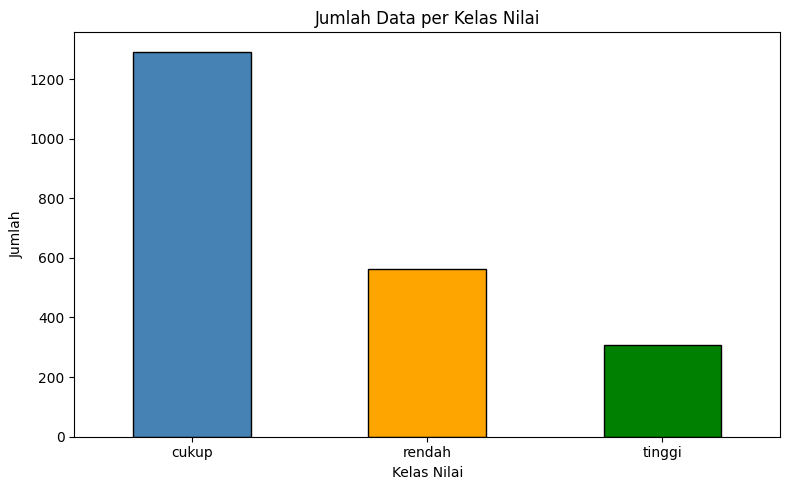

In [4]:
import matplotlib.pyplot as plt

class_counts = data['kelas_nilai_AN'].value_counts().sort_index()
print("Jumlah data per kelas_nilai:")
print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['steelblue', 'orange', 'green'], edgecolor='black')
plt.title('Jumlah Data per Kelas Nilai')
plt.xlabel('Kelas Nilai')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
data

,kd_sekolah,kurikulum,daerah_khusus,jenis_wilayah,status_wilayah,proporsi_pendidik_min_s1,proporsi_pendidik_sertifikasi,jumlah_peserta_didik,jumlah_pendidik,rasio_pendidik_peserta_didik,...,"Kepemilikan buku-buku tentang seni, musik, atau desain","Kepemilikan buku-buku tentang bahasa, termasuk kamus",Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah,Kepemilikan televisi layar datar,Kepemilikan mobil,Kepemilikan Pendingin Ruangan (AC),"Kepemilikan telepon seluler (handphone) dengan akses internet (misal, smartphone)",Kepemilikan komputer tablet (Tab/iPad),Kpemilikan karya-karya seni (misal: lukisan/patung seni),kelas_nilai_AN
0,8500067,Kurikulum 2013,Tidak,KABUPATEN,URBAN,100.0,0.0,94.0,5.0,18.8,...,Tidak ada,Tidak ada,Kira-kira 1-10 buku,Satu,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,rendah
1,8500067,Kurikulum 2013,Tidak,KABUPATEN,URBAN,100.0,0.0,94.0,5.0,18.8,...,Tidak ada,Kira-kira 11-25 buku,Kira-kira lebih dari 100 buku,Satu,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tiga atau lebih,rendah
2,8500067,Kurikulum 2013,Tidak,KABUPATEN,URBAN,100.0,0.0,94.0,5.0,18.8,...,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,cukup
3,8500067,Kurikulum 2013,Tidak,KABUPATEN,URBAN,100.0,0.0,94.0,5.0,18.8,...,Tidak ada,Tidak ada,Kira-kira 1-10 buku,Satu,Tidak ada,Tidak ada,Tiga atau lebih,Tidak ada,Tidak ada,rendah
4,8500067,Kurikulum 2013,Tidak,KABUPATEN,URBAN,100.0,0.0,94.0,5.0,18.8,...,Tidak ada,Tidak ada,Kira-kira 1-10 buku,Satu,Tidak ada,Tidak ada,Dua,Tidak ada,Tidak ada,cukup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2157,5100134,Kurikulum Merdeka,Tidak,KABUPATEN,RURAL,100.0,10.0,121.0,10.0,12.1,...,Kira-kira 1-10 buku,Kira-kira 1-10 buku,Kira-kira 1-10 buku,Satu,Tidak ada,Tidak ada,Dua,Satu,Tiga atau lebih,rendah
2158,5100134,Kurikulum Merdeka,Tidak,KABUPATEN,RURAL,100.0,10.0,121.0,10.0,12.1,...,Kira-kira 11-25 buku,Kira-kira 1-10 buku,Kira-kira lebih dari 100 buku,Dua,Satu,Tidak ada,Dua,Dua,Tiga atau lebih,rendah
2159,5100134,Kurikulum Merdeka,Tidak,KABUPATEN,RURAL,100.0,10.0,121.0,10.0,12.1,...,Kira-kira 1-10 buku,Kira-kira 1-10 buku,Kira-kira 1-10 buku,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,rendah
2160,5100134,Kurikulum Merdeka,Tidak,KABUPATEN,RURAL,100.0,10.0,121.0,10.0,12.1,...,Tidak ada,Kira-kira 1-10 buku,Kira-kira 1-10 buku,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,rendah


MAKE GRAF

In [6]:
import networkx as nx
from pyvis.network import Network
import pandas as pd


target_col = 'kelas_nilai_AN'

kolom_wilayah = [
     'daerah_khusus',
       'jenis_wilayah', 'status_wilayah'
]

kolom_sekolah = [
    'proporsi_pendidik_min_s1', 'proporsi_pendidik_sertifikasi', 
    'jumlah_peserta_didik', 'jumlah_pendidik', 'rasio_pendidik_peserta_didik', 
    'jumlah_r_kelas', 'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_rombel', 
    'jumlah_siswa_rombel', 'jumlah_siswa_penerima_PIP', 'rasio_siswa_penerima_PIP',
    'kurikulum', 
    'ketersediaan_internet', 'ketersediaan_listrik'
]

kolom_ortu = [
    'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
    'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?',
    'Apa pekerjaan ayahmu?',
    'Apa pekerjaan ibumu?'
]

kolom_siswa = [
    'Ada berapa keluarga yang tinggal bersama di rumahmu?',
    'Kepemilikan buku-buku fiksi/sastra seperti novel, kumpulan cerpen, atau kumpulan puisi',
    'Kepemilikan buku-buku tentang sains atau teknologi',
    'Kepemilikan buku-buku tentang seni, musik, atau desain',
    'Kepemilikan buku-buku tentang bahasa, termasuk kamus',
    'Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah',
    'Kepemilikan televisi layar datar', 
    'Kepemilikan mobil',
    'Kepemilikan Pendingin Ruangan (AC)',
    'Kepemilikan telepon seluler (handphone) dengan akses internet (misal, smartphone)',
    'Kepemilikan komputer tablet (Tab/iPad)',
    'Kpemilikan karya-karya seni (misal: lukisan/patung seni)',
    'Apakah kamu perempuan atau laki-laki?',
    'Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)',
    'Kepemilikan Meja belajar di rumah',
    'Tempat belajar yang tenang di rumah',
    'Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah',
    'Listrik dan lampu untuk belajar di rumah pada malam hari',
    'Kepemilikan perangkat lunak (software atau program komputer) pendidikan',
    'Sambungan ke internet di rumah',
    'Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)'
]


data['wilayah_idx'] = data.groupby(kolom_wilayah).ngroup()

data['ortu_idx'] = data.groupby(kolom_ortu).ngroup()

sample_siswa = data['kd_siswa_an'].unique()
data_sample = data[data['kd_siswa_an'].isin(sample_siswa)]

G = nx.Graph()

In [7]:
for idx, row in data.iterrows():
    id_siswa = f"Siswa_{row['kd_siswa_an']}"
    id_sekolah = f"Sekolah_{row['kd_sekolah']}"
    id_wilayah = f"Wilayah_{row['wilayah_idx']}"
    id_ortu = f"Ortu_{row['ortu_idx']}"
    
    attr_siswa = {col: row[col] for col in kolom_siswa if pd.notna(row[col])}
    attr_siswa['target_kelas_nilai'] = row.get(target_col, None)
    G.add_node(id_siswa, tipe='Siswa', **attr_siswa)
    
    attr_sekolah = {col: row[col] for col in kolom_sekolah if pd.notna(row[col])}
    G.add_node(id_sekolah, tipe='Sekolah', **attr_sekolah)
    
    attr_wilayah = {col: row[col] for col in kolom_wilayah if pd.notna(row[col])}
    G.add_node(id_wilayah, tipe='Wilayah', **attr_wilayah)
    
    attr_ortu = {col: row[col] for col in kolom_ortu if pd.notna(row[col])}
    G.add_node(id_ortu, tipe='Ortu', **attr_ortu)
    

    G.add_edge(id_siswa, id_sekolah)
    G.add_edge(id_sekolah, id_wilayah)
    G.add_edge(id_siswa, id_ortu)

In [ ]:
import plotly.graph_objects as go
import networkx as nx
import random


sekolah_nodes = [n for n, attr in G.nodes(data=True) if attr.get('tipe') == 'Sekolah']

random.seed(42) # 
sampel_sekolah = random.sample(sekolah_nodes, min(3, len(sekolah_nodes)))

sub_nodes = set(sampel_sekolah)


for sekolah in sampel_sekolah:
    tetangga_sekolah = list(G.neighbors(sekolah))
    sub_nodes.update(tetangga_sekolah)
    

    for tetangga in tetangga_sekolah:
        if G.nodes[tetangga].get('tipe') == 'Siswa':
            ortu_siswa = list(G.neighbors(tetangga))
            sub_nodes.update(ortu_siswa)


H = G.subgraph(list(sub_nodes))

pos = nx.spring_layout(H, k=0.15, seed=42)

node_x = []
node_y = []
node_text = []
node_color = []
node_size = []


for node in H.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    attrs = H.nodes[node]
    node_type = attrs.get("tipe", "Unknown")

    if node_type == "Sekolah":
        node_color.append("red")
        node_size.append(15)
        node_text.append(
            "<b>SEKOLAH</b><br>"
            f"ID: {node}<br>"
            f"Proporsi S1: {attrs.get('proporsi_pendidik_min_s1', '-')}<br>"
            f"Proporsi Sertifikasi: {attrs.get('proporsi_pendidik_sertifikasi', '-')}<br>"
            f"Jumlah Pendidik: {attrs.get('jumlah_pendidik', '-')}<br>"
            f"Rasio Guru/Murid: {attrs.get('rasio_pendidik_peserta_didik', '-')}<br>"
            f"Jumlah Peserta Didik: {attrs.get('jumlah_peserta_didik', '-')}<br>"
            f"Jumlah Ruang Kelas: {attrs.get('jumlah_r_kelas', '-')}<br>"
            f"Ketersediaan Internet: {attrs.get('ketersediaan_internet', '-')}<br>"
            f"Ketersediaan Listrik: {attrs.get('ketersediaan_listrik', '-')}<br>"
            f"Jumlah Komputer: {attrs.get('jumlah_komp_milik', '-')}<br>"
            f"Jumlah Perpus: {attrs.get('jumlah_perpus', '-')}<br>"
            f"Jumlah Rombel: {attrs.get('jumlah_rombel', '-')}<br>"
            f"Rata Siswa/Rombel: {attrs.get('jumlah_siswa_rombel', '-')}<br>"
            f"Jml Penerima PIP: {attrs.get('jumlah_siswa_penerima_PIP', '-')}<br>"
            f"Rasio Penerima PIP: {attrs.get('rasio_siswa_penerima_PIP', '-')}<br>"
            f"Kurikulum: {attrs.get('kurikulum', '-')}"
        )

    elif node_type == "Wilayah":
        node_color.append("lightgreen")
        node_size.append(12)
        node_text.append(
            "<b>WILAYAH</b><br>"
            f"ID: {node}<br>"
            f"Daerah Khusus: {attrs.get('daerah_khusus', '-')}<br>"
            f"Wilayah Bagian: {attrs.get('wilayah_bagian', '-')}<br>"
            f"Jenis Wilayah: {attrs.get('jenis_wilayah', '-')}<br>"
            f"Status: {attrs.get('status_wilayah', '-')}"
        )

    elif node_type == "Ortu":
        node_color.append("orange")
        node_size.append(10)
        node_text.append(
            "<b>PROFIL ORTU</b><br>"
            f"Node ID: {node}<br>"
            f"Pendidikan Ayah: {attrs.get('Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?', '-')}<br>"
            f"Pendidikan Ibu: {attrs.get('Apa jenjang sekolah tertinggi yang diselesaikan ibumu?', '-')}<br>"
            f"Pekerjaan Ayah: {attrs.get('Apa pekerjaan ayahmu?', '-')}<br>"
            f"Pekerjaan Ibu: {attrs.get('Apa pekerjaan ibumu?', '-')}"
        )

    elif node_type == "Siswa":
        node_color.append("skyblue")
        node_size.append(7)
        node_text.append(
            "<b>SISWA</b><br>"
            f"ID: {node}<br>"
            f"Gender: {attrs.get('Apakah kamu perempuan atau laki-laki?', '-')}<br>"
            f"Family Size: {attrs.get('Ada berapa keluarga yang tinggal bersama di rumahmu?', '-')}<br>"
            f"Meja Belajar: {attrs.get('Kepemilikan Meja belajar di rumah', '-')}<br>"
            f"Kamar Sendiri: {attrs.get('Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)', '-')}<br>"
            f"Tempat Tenang: {attrs.get('Tempat belajar yang tenang di rumah', '-')}<br>"
            f"Listrik Belajar: {attrs.get('Listrik dan lampu untuk belajar di rumah pada malam hari', '-')}<br>"
            f"Komputer/Laptop: {attrs.get('Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah', '-')}<br>"
            f"Internet: {attrs.get('Sambungan ke internet di rumah', '-')}<br>"
            f"Smartphone: {attrs.get('Kepemilikan telepon seluler (handphone) dengan akses internet (misal, smartphone)', '-')}<br>"
            f"Buku Tugas: {attrs.get('Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah', '-')}<br>"
            f"Kelas Nilai AN: {attrs.get('target_kelas_nilai', '-')}"
        )


edge_x = []
edge_y = []

for edge in H.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.3, color="#888"),
    hoverinfo="none",
    mode="lines"
)


node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    hovertemplate="%{text}<extra></extra>",
    text=node_text,
    marker=dict(
        showscale=False,
        color=node_color,
        size=node_size,
        line=dict(width=1, color="white")
    )
)

legend_data = [
    ("Sekolah", "red"),
    ("Wilayah", "lightgreen"),
    ("Profil Ortu", "orange"),
    ("Siswa", "skyblue")
]

legend_traces = [
    go.Scatter(x=[None], y=[None], mode="markers",
               marker=dict(size=10, color=c), name=l)
    for l, c in legend_data
]

fig = go.Figure(
    data=[edge_trace, node_trace] + legend_traces,
    layout=go.Layout(
        title="<b>Visualisasi Interaktif Graph Asesmen Nasional (Sampel Ego Graph)</b>",
        title_x=0.5,
        showlegend=True,
        hovermode="closest",
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor="white"
    )
)

fig.show()

# encodinggg


# encodinggg


saya hanya memberdaan variabel data disini untuk encodiung biar tidak tumpang tih ajasigb

In [9]:
import pandas as pd

data_for_encod = pd.read_csv('data_timur.csv')
data_for_encod = data_for_encod.drop('Unnamed: 0',axis=1)

kolom_nominal = [
    'kurikulum',
    'daerah_khusus',
    'jenis_wilayah',
    'status_wilayah',
    'ketersediaan_internet',
    'ketersediaan_listrik',
    'Apakah kamu perempuan atau laki-laki?',
    'Apa pekerjaan ayahmu?',
    'Apa pekerjaan ibumu?',
    'Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)',
    'Kepemilikan Meja belajar di rumah',
    'Tempat belajar yang tenang di rumah',
    'Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah',
    'Listrik dan lampu untuk belajar di rumah pada malam hari',
    'Kepemilikan perangkat lunak (software atau program komputer) pendidikan',
    'Sambungan ke internet di rumah',
    'Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)',
]

kolom_keluarga = ['Ada berapa keluarga yang tinggal bersama di rumahmu?']
kolom_nilai = ['kelas_nilai_AN']

kolom_pendidikan = [
    'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
    'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?'
]

kolom_buku = [
    'Kepemilikan buku-buku fiksi/sastra seperti novel, kumpulan cerpen, atau kumpulan puisi',
    'Kepemilikan buku-buku tentang sains atau teknologi',
    'Kepemilikan buku-buku tentang seni, musik, atau desain',
    'Kepemilikan buku-buku tentang bahasa, termasuk kamus',
    'Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah'
]

kolom_gadget = [
    'Kepemilikan televisi layar datar',
    'Kepemilikan mobil',
    'Kepemilikan Pendingin Ruangan (AC)',
    'Kepemilikan telepon seluler (handphone) dengan akses internet (misal, smartphone)',
    'Kepemilikan komputer tablet (Tab/iPad)',
    'Kpemilikan karya-karya seni (misal: lukisan/patung seni)'
]

mapping_pendidikan = {
    'Tidak Tahu': 0,
    'SD': 1,
    'SMP': 2,
    'SMA/SMK': 3,
    'Diploma (D1, D2, atau D3)': 4,
    'Sarjana (S1)': 5,
    'Master (S2)': 6,
    'Doktor (S3)': 7
}

mapping_buku = {
    'Tidak ada': 0,
    'Kira-kira 1-10 buku': 1,
    'Kira-kira 11-25 buku': 2,
    'Kira-kira 26-100 buku': 3,
    'Kira-kira lebih dari 100 buku': 4
}

mapping_gadget = {
    'Tidak ada': 0,
    'Satu': 1,
    'Dua': 2,
    'Tiga atau lebih': 3
}

mapping_keluarga = {
    'Hanya keluarga intiku sendiri (orang tua dan saudara kandungku saja)':0,
       'Keluargaku bersama tiga atau lebih keluarga lain':3,
       'Keluargaku bersama dua keluarga lain':2,
       'Keluargaku bersama satu keluarga lain':1
}

mapping_nilai = {'rendah': 0, 'cukup':1, 'tinggi': 2}


# --- PROSES ORDINAL ENCODING ---
for col in kolom_pendidikan:
    data_for_encod[col] = data_for_encod[col].map(mapping_pendidikan)

for col in kolom_buku:
    data_for_encod[col] = data_for_encod[col].map(mapping_buku)

for col in kolom_gadget:
    data_for_encod[col] = data_for_encod[col].map(mapping_gadget)
    
for col in kolom_keluarga:
    data_for_encod[col] = data_for_encod[col].map(mapping_keluarga)
    
for col in kolom_nilai:
    data_for_encod[col] = data_for_encod[col].map(mapping_nilai)


print(data_for_encod.shape)


data_encod = pd.get_dummies(data_for_encod, columns=kolom_nominal, dtype=int)
data_encod.shape

(2162, 47)


(2162, 88)

In [10]:
data_encod.columns

Index(['kd_sekolah', 'wilayah_bagian', 'proporsi_pendidik_min_s1',
       'proporsi_pendidik_sertifikasi', 'jumlah_peserta_didik',
       'jumlah_pendidik', 'rasio_pendidik_peserta_didik', 'jumlah_r_kelas',
       'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_rombel',
       'jumlah_siswa_rombel', 'jumlah_siswa_penerima_PIP',
       'rasio_siswa_penerima_PIP', 'kd_siswa_an',
       'Ada berapa keluarga yang tinggal bersama di rumahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?',
       'Kepemilikan buku-buku fiksi/sastra seperti novel, kumpulan cerpen, atau kumpulan puisi',
       'Kepemilikan buku-buku tentang sains atau teknologi',
       'Kepemilikan buku-buku tentang seni, musik, atau desain',
       'Kepemilikan buku-buku tentang bahasa, termasuk kamus',
       'Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah',
       'Kepemilikan televisi layar datar', 'Kepemilikan m

In [11]:
data_encod.columns

Index(['kd_sekolah', 'wilayah_bagian', 'proporsi_pendidik_min_s1',
       'proporsi_pendidik_sertifikasi', 'jumlah_peserta_didik',
       'jumlah_pendidik', 'rasio_pendidik_peserta_didik', 'jumlah_r_kelas',
       'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_rombel',
       'jumlah_siswa_rombel', 'jumlah_siswa_penerima_PIP',
       'rasio_siswa_penerima_PIP', 'kd_siswa_an',
       'Ada berapa keluarga yang tinggal bersama di rumahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
       'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?',
       'Kepemilikan buku-buku fiksi/sastra seperti novel, kumpulan cerpen, atau kumpulan puisi',
       'Kepemilikan buku-buku tentang sains atau teknologi',
       'Kepemilikan buku-buku tentang seni, musik, atau desain',
       'Kepemilikan buku-buku tentang bahasa, termasuk kamus',
       'Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah',
       'Kepemilikan televisi layar datar', 'Kepemilikan m

In [12]:
data_encod

,kd_sekolah,wilayah_bagian,proporsi_pendidik_min_s1,proporsi_pendidik_sertifikasi,jumlah_peserta_didik,jumlah_pendidik,rasio_pendidik_peserta_didik,jumlah_r_kelas,jumlah_komp_milik,jumlah_perpus,...,"Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah_Ada","Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah_Tidak ada",Listrik dan lampu untuk belajar di rumah pada malam hari_Ada,Listrik dan lampu untuk belajar di rumah pada malam hari_Tidak ada,Kepemilikan perangkat lunak (software atau program komputer) pendidikan_Ada,Kepemilikan perangkat lunak (software atau program komputer) pendidikan_Tidak ada,Sambungan ke internet di rumah_Ada,Sambungan ke internet di rumah_Tidak ada,"Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)_Ada","Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)_Tidak ada"
0,8500067,Indonesia Timur,100.0,0.0,94.0,5.0,18.8,8.0,0.0,0.0,...,0,1,1,0,0,1,0,1,0,1
1,8500067,Indonesia Timur,100.0,0.0,94.0,5.0,18.8,8.0,0.0,0.0,...,0,1,1,0,0,1,0,1,0,1
2,8500067,Indonesia Timur,100.0,0.0,94.0,5.0,18.8,8.0,0.0,0.0,...,0,1,1,0,0,1,0,1,0,1
3,8500067,Indonesia Timur,100.0,0.0,94.0,5.0,18.8,8.0,0.0,0.0,...,0,1,1,0,0,1,1,0,0,1
4,8500067,Indonesia Timur,100.0,0.0,94.0,5.0,18.8,8.0,0.0,0.0,...,0,1,1,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2157,5100134,Indonesia Timur,100.0,10.0,121.0,10.0,12.1,3.0,1.0,0.0,...,1,0,1,0,1,0,1,0,1,0
2158,5100134,Indonesia Timur,100.0,10.0,121.0,10.0,12.1,3.0,1.0,0.0,...,0,1,1,0,1,0,0,1,1,0
2159,5100134,Indonesia Timur,100.0,10.0,121.0,10.0,12.1,3.0,1.0,0.0,...,0,1,0,1,0,1,0,1,0,1
2160,5100134,Indonesia Timur,100.0,10.0,121.0,10.0,12.1,3.0,1.0,0.0,...,1,0,1,0,1,0,1,0,1,0


# to pytrorchh

yg msuk jadi fitur adadlah hasill encodd


In [13]:
import pandas as pd
import torch
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData


kolom_identitas = ['kd_sekolah', 'kd_siswa_an']
target_col = 'kelas_nilai_AN'

kolom_wilayah = [
    'daerah_khusus_Tidak', 'daerah_khusus_Ya', 
    'jenis_wilayah_KABUPATEN', 'jenis_wilayah_KOTA', 
    'status_wilayah_RURAL', 'status_wilayah_URBAN'
]

kolom_sekolah = [
    'proporsi_pendidik_min_s1', 'proporsi_pendidik_sertifikasi', 
    'jumlah_peserta_didik', 'jumlah_pendidik', 'rasio_pendidik_peserta_didik', 
    'jumlah_r_kelas', 'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_rombel', 
    'jumlah_siswa_rombel', 'jumlah_siswa_penerima_PIP', 'rasio_siswa_penerima_PIP',
    'kurikulum_Kurikulum 2013', 'kurikulum_Kurikulum Merdeka', 
    'ketersediaan_internet_Ada', 
    'ketersediaan_internet_Tidak Ada',
    'ketersediaan_listrik_Ada'
]

kolom_ortu = [
    'Ada berapa keluarga yang tinggal bersama di rumahmu?',
    'Apa jenjang sekolah tertinggi yang diselesaikan ayahmu?',
    'Apa jenjang sekolah tertinggi yang diselesaikan ibumu?',
    'Apa pekerjaan ayahmu?_Anggota legislatif (DPR atau DPRD) atau pemimpin pemerintah (seperti gubernur, walikota, bupati)',
    'Apa pekerjaan ayahmu?_Anggota militer (TNI/tentara) atau polisi (Polri)',
    'Apa pekerjaan ayahmu?_Bekerja mandiri dengan keterampilan khusus (seperti montir bengkel, penjahit, tukang kayu, bertani di ladang sendiri, nelayan dengan kapal sendiri, dll.)',
    'Apa pekerjaan ayahmu?_Buruh pabrik/tani/tambang, asisten/pembantu rumah tangga, pengemudi/sopir (termasuk taksi online), petugas keamanan, petugas kebersihan, dan karyawan usaha kecil (pelayan toko, mini market, dll)',
    'Apa pekerjaan ayahmu?_Manajer atau pemimpin/kepala/pejabat di kantor pemerintah, perusahaan BUMN, atau perusahaan swasta.',
    'Apa pekerjaan ayahmu?_Pekerja administratif (seperti sekretaris, tata usaha, receptionist, front office, costumer service) di kantor pemerintah (termasuk PNS), di perusahaan BUMN, dan di perusahaan swasta.',
    'Apa pekerjaan ayahmu?_Pemilik perusahaan besar (seperti pabrik besar, restoran besar, toko dengan banyak cabang, dll.',
    'Apa pekerjaan ayahmu?_Pemilik usaha kecil (seperti pemilik toko kecil, bengkel, warung, pemilik rental mobil, dll.)',
    'Apa pekerjaan ayahmu?_Pensiunan dari karyawan pemerintah, perusahaan swasta, militer, atau polisi',
    'Apa pekerjaan ayahmu?_Perwira militer (TNI/tentara) atau polisi (Polri)',
    'Apa pekerjaan ayahmu?_Profesional (seperti dosen, guru, dokter, bidan, pengacara, jaksa, insinyur/engineer, musisi, nakoda kapal, pilot, dll.)',
    'Apa pekerjaan ayahmu?_Tenaga pemasaran (seperti sales, marketing)',
    'Apa pekerjaan ayahmu?_Tidak bekerja (termasuk jika sudah meninggal), mengurus rumah tangga (termasuk ibu rumah tangga), atau kerja serabutan (tidak jelas)',
    'Apa pekerjaan ayahmu?_Tidak tahu.',
    'Apa pekerjaan ibumu?_Anggota legislatif (DPR atau DPRD) atau pemimpin pemerintah (seperti gubernur, walikota, bupati)',
    'Apa pekerjaan ibumu?_Anggota militer (TNI/tentara) atau polisi (Polri)',
    'Apa pekerjaan ibumu?_Bekerja mandiri dengan keterampilan khusus (seperti montir bengkel, penjahit, tukang kayu, bertani di ladang sendiri, nelayan dengan kapal sendiri, dll.)',
    'Apa pekerjaan ibumu?_Buruh pabrik/tani/tambang, asisten/pembantu rumah tangga, pengemudi/sopir (termasuk taksi online), petugas keamanan, petugas kebersihan, dan karyawan usaha kecil (pelayan toko, mini market, dll)',
    'Apa pekerjaan ibumu?_Manajer atau pemimpin/kepala/pejabat di kantor pemerintah, perusahaan BUMN, atau perusahaan swasta.',
    'Apa pekerjaan ibumu?_Pekerja administratif (seperti sekretaris, tata usaha, receptionist, front office, costumer service) di kantor pemerintah (termasuk PNS), di perusahaan BUMN, dan di perusahaan swasta.',
    'Apa pekerjaan ibumu?_Pemilik perusahaan besar (seperti pabrik besar, restoran besar, toko dengan banyak cabang, dll.',
    'Apa pekerjaan ibumu?_Pemilik usaha kecil (seperti pemilik toko kecil, bengkel, warung, pemilik rental mobil, dll.)',
    'Apa pekerjaan ibumu?_Pensiunan dari karyawan pemerintah, perusahaan swasta, militer, atau polisi',
    'Apa pekerjaan ibumu?_Perwira militer (TNI/tentara) atau polisi (Polri)',
    'Apa pekerjaan ibumu?_Profesional (seperti dosen, guru, dokter, bidan, pengacara, jaksa, insinyur/engineer, musisi, nakoda kapal, pilot, dll.)',
    'Apa pekerjaan ibumu?_Tenaga pemasaran (seperti sales, marketing)',
    'Apa pekerjaan ibumu?_Tidak bekerja (termasuk jika sudah meninggal), mengurus rumah tangga (termasuk ibu rumah tangga), atau kerja serabutan (tidak jelas)',
    'Apa pekerjaan ibumu?_Tidak tahu.'
]

kolom_siswa = [
    'Kepemilikan buku-buku fiksi/sastra seperti novel, kumpulan cerpen, atau kumpulan puisi',
    'Kepemilikan buku-buku tentang sains atau teknologi',
    'Kepemilikan buku-buku tentang seni, musik, atau desain',
    'Kepemilikan buku-buku tentang bahasa, termasuk kamus',
    'Kepemilikan buku-buku yang bisa membantumu mengerjakan tugas-tugas sekolah',
    'Kepemilikan televisi layar datar', 
    'Kepemilikan mobil',
    'Kepemilikan Pendingin Ruangan (AC)',
    'Kepemilikan telepon seluler (handphone) dengan akses internet (misal, smartphone)',
    'Kepemilikan komputer tablet (Tab/iPad)',
    'Kpemilikan karya-karya seni (misal: lukisan/patung seni)',
    'Apakah kamu perempuan atau laki-laki?_Laki-laki',
    'Apakah kamu perempuan atau laki-laki?_Perempuan',
    'Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)_Ada',
    'Kamar tidur untuk dirimu sendiri (tidak berbagi dengan saudara atau orang lain)_Tidak ada',
    'Kepemilikan Meja belajar di rumah_Ada',
    'Kepemilikan Meja belajar di rumah_Tidak ada',
    'Tempat belajar yang tenang di rumah_Ada',
    'Tempat belajar yang tenang di rumah_Tidak ada',
    'Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah_Ada',
    'Komputer, laptop, atau tablet yang bisa kamu pakai untuk keperluan belajar atau tugas sekolah_Tidak ada',
    'Listrik dan lampu untuk belajar di rumah pada malam hari_Ada',
    'Listrik dan lampu untuk belajar di rumah pada malam hari_Tidak ada',
    'Kepemilikan perangkat lunak (software atau program komputer) pendidikan_Ada',
    'Kepemilikan perangkat lunak (software atau program komputer) pendidikan_Tidak ada',
    'Sambungan ke internet di rumah_Ada',
    'Sambungan ke internet di rumah_Tidak ada',
    'Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)_Ada',
    'Kepemilikan alat baca buku digital (seperti Kindle, Kobo, dll)_Tidak ada'
]



data_encod['id_wilayah'] = data_encod[kolom_wilayah].astype(str).agg('-'.join, axis=1)
data_encod['id_ortu'] = data_encod[kolom_ortu].astype(str).agg('-'.join, axis=1)

data_encod['siswa_idx'] = data_encod['kd_siswa_an'].astype('category').cat.codes
data_encod['sekolah_idx'] = data_encod['kd_sekolah'].astype('category').cat.codes
data_encod['wilayah_idx'] = data_encod['id_wilayah'].astype('category').cat.codes
data_encod['ortu_idx'] = data_encod['id_ortu'].astype('category').cat.codes




def extract_node_features(df_source, idx_col, feature_cols):
    """Menghapus duplikasi baris per objek dan mengubahnya menjadi Float Tensor."""
    df_unique = df_source[[idx_col] + feature_cols].drop_duplicates(idx_col).sort_values(idx_col)
    return torch.tensor(df_unique[feature_cols].values, dtype=torch.float)

X_wilayah = extract_node_features(data_encod, 'wilayah_idx', kolom_wilayah)
X_sekolah = extract_node_features(data_encod, 'sekolah_idx', kolom_sekolah)
X_ortu    = extract_node_features(data_encod, 'ortu_idx', kolom_ortu)
X_siswa   = extract_node_features(data_encod, 'siswa_idx', kolom_siswa)

df_target = data_encod[['siswa_idx', target_col]].drop_duplicates('siswa_idx').sort_values('siswa_idx')
Y_siswa = torch.tensor(df_target[target_col].values, dtype=torch.long)



data = HeteroData()

data['siswa'].x = X_siswa
data['siswa'].y = Y_siswa
data['sekolah'].x = X_sekolah
data['wilayah'].x = X_wilayah
data['profil_ortu'].x = X_ortu


data['siswa', 'belajar_di', 'sekolah'].edge_index = torch.tensor([
    data_encod['siswa_idx'].values, 
    data_encod['sekolah_idx'].values
], dtype=torch.long)

df_sek_wil = data_encod[['sekolah_idx', 'wilayah_idx']].drop_duplicates()
data['sekolah', 'berlokasi_di', 'wilayah'].edge_index = torch.tensor([
    df_sek_wil['sekolah_idx'].values, 
    df_sek_wil['wilayah_idx'].values
], dtype=torch.long)

data['siswa', 'memiliki', 'profil_ortu'].edge_index = torch.tensor([
    data_encod['siswa_idx'].values, 
    data_encod['ortu_idx'].values
], dtype=torch.long)

data = T.ToUndirected()(data)
print(data)

HeteroData(
  siswa={
    x=[2162, 29],
    y=[2162],
  },
  sekolah={ x=[79, 17] },
  wilayah={ x=[5, 6] },
  profil_ortu={ x=[1072, 31] },
  (siswa, belajar_di, sekolah)={ edge_index=[2, 2162] },
  (sekolah, berlokasi_di, wilayah)={ edge_index=[2, 79] },
  (siswa, memiliki, profil_ortu)={ edge_index=[2, 2162] },
  (sekolah, rev_belajar_di, siswa)={ edge_index=[2, 2162] },
  (wilayah, rev_berlokasi_di, sekolah)={ edge_index=[2, 79] },
  (profil_ortu, rev_memiliki, siswa)={ edge_index=[2, 2162] }
)


C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_7344\484342166.py:130: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)



In [14]:
import torch

num_siswa = data['siswa'].num_nodes
y = data['siswa'].y

print("Jumlah siswa:", num_siswa)
print("Label siswa:", y)

Jumlah siswa: 2162
Label siswa: tensor([0, 1, 1,  ..., 1, 1, 0])


In [15]:
(data['sekolah'].x < 0).any().item()

False

In [16]:
import torch_geometric.transforms as T

transform_split = T.RandomNodeSplit(
    split='train_rest', 
    num_val=0.1,        
    num_test=0.1        
)

data = transform_split(data)

print(f"Jumlah Train : {data['siswa'].train_mask.sum().item()}")
print(f"Jumlah Val   : {data['siswa'].val_mask.sum().item()}")
print(f"Jumlah Test  : {data['siswa'].test_mask.sum().item()}")

Jumlah Train : 1730
Jumlah Val   : 216
Jumlah Test  : 216


In [17]:
import torch

print("=== DISTRIBUSI KELAS terpliiiit===\n")
y_siswa = data['siswa'].y

def bedah_kelas(nama_subset, mask):
    label_tersaring = y_siswa[mask]
    
    total_node = label_tersaring.size(0)
    print(f"[{nama_subset.upper()}] - Total: {total_node} siswa")

    kelas_unik, jumlah = torch.unique(label_tersaring, return_counts=True)
    
    for k, j in zip(kelas_unik, jumlah):
        print(f"  - Kelas {k.item()}: {j.item()} siswa")
    print("-" * 45)

bedah_kelas("Train (80%)", data['siswa'].train_mask)
bedah_kelas("Validation (10%)", data['siswa'].val_mask)
bedah_kelas("Test (10%)", data['siswa'].test_mask)

total_populasi = y_siswa.size(0)
print(f"[POPULASI AWAL] - Total Keseluruhan: {total_populasi} siswa")
kelas_unik_pop, jumlah_pop = torch.unique(y_siswa, return_counts=True)
for k, j in zip(kelas_unik_pop, jumlah_pop):
    print(f"  - Kelas {k.item()}: {j.item()} siswa")

=== DISTRIBUSI KELAS terpliiiit===

[TRAIN (80%)] - Total: 1730 siswa
  - Kelas 0: 445 siswa
  - Kelas 1: 1034 siswa
  - Kelas 2: 251 siswa
---------------------------------------------
[VALIDATION (10%)] - Total: 216 siswa
  - Kelas 0: 58 siswa
  - Kelas 1: 136 siswa
  - Kelas 2: 22 siswa
---------------------------------------------
[TEST (10%)] - Total: 216 siswa
  - Kelas 0: 59 siswa
  - Kelas 1: 122 siswa
  - Kelas 2: 35 siswa
---------------------------------------------
[POPULASI AWAL] - Total Keseluruhan: 2162 siswa
  - Kelas 0: 562 siswa
  - Kelas 1: 1292 siswa
  - Kelas 2: 308 siswa


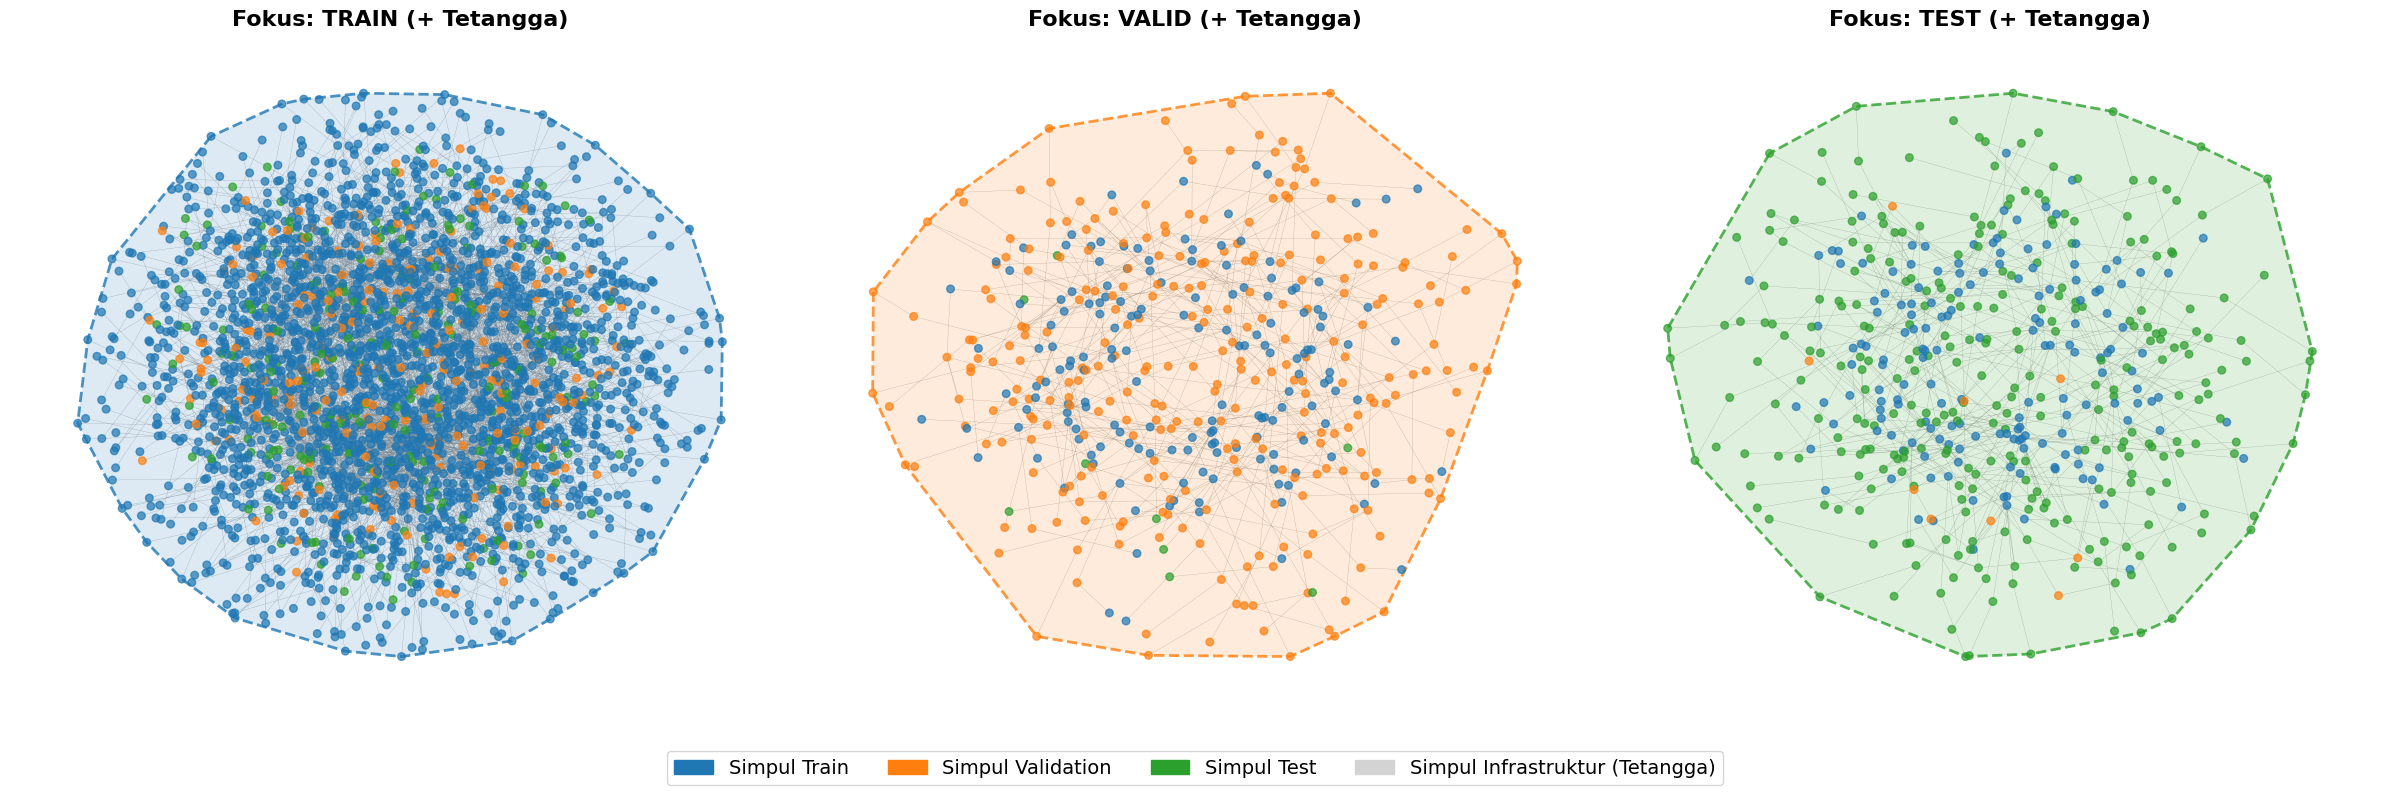

# Modell

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha 
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [19]:
import torch_geometric.transforms as T
from torch_geometric.nn import GraphConv,SAGEConv, to_hetero

class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GraphConv((-1, -1), hidden_channels, bias=True)
        self.conv2 = GraphConv((-1, -1), hidden_channels, bias=True)
        self.conv3 = GraphConv((-1, -1), hidden_channels, bias=True)
        self.conv4 = GraphConv((-1, -1), out_channels, bias=True)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index).relu()
        x = self.conv4(x, edge_index)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

model = GNN(hidden_channels=64, out_channels=3)
model = to_hetero(model, data.metadata(), aggr='mean')

criterion = FocalLoss(gamma=2.0) 

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [20]:
model.print_readable()

class GraphModule(torch.nn.Module):
    def forward(self, x, edge_index):
        # No stacktrace found for following nodes
        x_dict = torch_geometric_nn_to_hetero_transformer_get_dict(x);  x = None
        x__siswa = x_dict.get('siswa', None)
        x__sekolah = x_dict.get('sekolah', None)
        x__wilayah = x_dict.get('wilayah', None)
        x__profil_ortu = x_dict.get('profil_ortu', None);  x_dict = None
        edge_index_dict = torch_geometric_nn_to_hetero_transformer_get_dict(edge_index);  edge_index = None
        edge_index__siswa__belajar_di__sekolah = edge_index_dict.get(('siswa', 'belajar_di', 'sekolah'), None)
        edge_index__sekolah__berlokasi_di__wilayah = edge_index_dict.get(('sekolah', 'berlokasi_di', 'wilayah'), None)
        edge_index__siswa__memiliki__profil_ortu = edge_index_dict.get(('siswa', 'memiliki', 'profil_ortu'), None)
        edge_index__sekolah__rev_belajar_di__siswa = edge_index_dict.get(('sekolah', 'rev_belajar_di', 'siswa'), None)
       

"class GraphModule(torch.nn.Module):\n    def forward(self, x, edge_index):\n        # No stacktrace found for following nodes\n        x_dict = torch_geometric_nn_to_hetero_transformer_get_dict(x);  x = None\n        x__siswa = x_dict.get('siswa', None)\n        x__sekolah = x_dict.get('sekolah', None)\n        x__wilayah = x_dict.get('wilayah', None)\n        x__profil_ortu = x_dict.get('profil_ortu', None);  x_dict = None\n        edge_index_dict = torch_geometric_nn_to_hetero_transformer_get_dict(edge_index);  edge_index = None\n        edge_index__siswa__belajar_di__sekolah = edge_index_dict.get(('siswa', 'belajar_di', 'sekolah'), None)\n        edge_index__sekolah__berlokasi_di__wilayah = edge_index_dict.get(('sekolah', 'berlokasi_di', 'wilayah'), None)\n        edge_index__siswa__memiliki__profil_ortu = edge_index_dict.get(('siswa', 'memiliki', 'profil_ortu'), None)\n        edge_index__sekolah__rev_belajar_di__siswa = edge_index_dict.get(('sekolah', 'rev_belajar_di', 'siswa'), 

In [21]:
data.metadata()

(['siswa', 'sekolah', 'wilayah', 'profil_ortu'],
 [('siswa', 'belajar_di', 'sekolah'),
  ('sekolah', 'berlokasi_di', 'wilayah'),
  ('siswa', 'memiliki', 'profil_ortu'),
  ('sekolah', 'rev_belajar_di', 'siswa'),
  ('wilayah', 'rev_berlokasi_di', 'sekolah'),
  ('profil_ortu', 'rev_memiliki', 'siswa')])

In [22]:
history = {
    'epoch': [],
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

def train():
    model.train()
    optimizer.zero_grad()

    out_dict = model(data.x_dict, data.edge_index_dict)
    out = out_dict['siswa']

    mask = data['siswa'].train_mask
    loss = criterion(out[mask], data['siswa'].y[mask])

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(mask):
    model.eval()

    out_dict = model(data.x_dict, data.edge_index_dict)
    out = out_dict['siswa']

    loss = criterion(out[mask], data['siswa'].y[mask]).item()

    pred = out[mask].argmax(dim=-1)
    correct = pred.eq(data['siswa'].y[mask]).sum().item()
    acc = correct / mask.sum().item()

    return loss, acc, pred, data['siswa'].y[mask]

In [24]:
epochs = 500

print(f"Mulai pelatihan di device: {device}\n" + "="*40)

for epoch in range(1, epochs + 1):
    train_loss = train()

    _, train_acc, _, _ = evaluate(data['siswa'].train_mask)
    val_loss, val_acc, _, _ = evaluate(data['siswa'].val_mask)
    test_loss, test_acc, _, _ = evaluate(data['siswa'].test_mask)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if epoch % 10 == 0:
        print(
            f'Epoch: {epoch:03d} | '
            f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | '
            f'Test Acc: {test_acc:.4f}'
        )

Mulai pelatihan di device: cpu
Epoch: 010 | Train Loss: 12.0189, Train Acc: 0.5306 | Val Loss: 9.3071, Val Acc: 0.5694 | Test Acc: 0.5463
Epoch: 020 | Train Loss: 1.5549, Train Acc: 0.6081 | Val Loss: 1.2762, Val Acc: 0.6296 | Test Acc: 0.5741
Epoch: 030 | Train Loss: 0.6928, Train Acc: 0.5694 | Val Loss: 0.4754, Val Acc: 0.6157 | Test Acc: 0.5602
Epoch: 040 | Train Loss: 0.3999, Train Acc: 0.5815 | Val Loss: 0.3517, Val Acc: 0.6204 | Test Acc: 0.5787
Epoch: 050 | Train Loss: 0.3462, Train Acc: 0.5202 | Val Loss: 0.3766, Val Acc: 0.5046 | Test Acc: 0.5694
Epoch: 060 | Train Loss: 0.3282, Train Acc: 0.6179 | Val Loss: 0.3171, Val Acc: 0.6250 | Test Acc: 0.6157
Epoch: 070 | Train Loss: 0.3092, Train Acc: 0.5960 | Val Loss: 0.2969, Val Acc: 0.5926 | Test Acc: 0.5833
Epoch: 080 | Train Loss: 0.2983, Train Acc: 0.6260 | Val Loss: 0.2956, Val Acc: 0.5972 | Test Acc: 0.6019
Epoch: 090 | Train Loss: 0.2867, Train Acc: 0.6376 | Val Loss: 0.2974, Val Acc: 0.6250 | Test Acc: 0.6065
Epoch: 100 | T

# fluktuasi EPOCH


latex janagn pake rezize box


scala log

beri contoh ilustrasii dan skenario dari input ke output

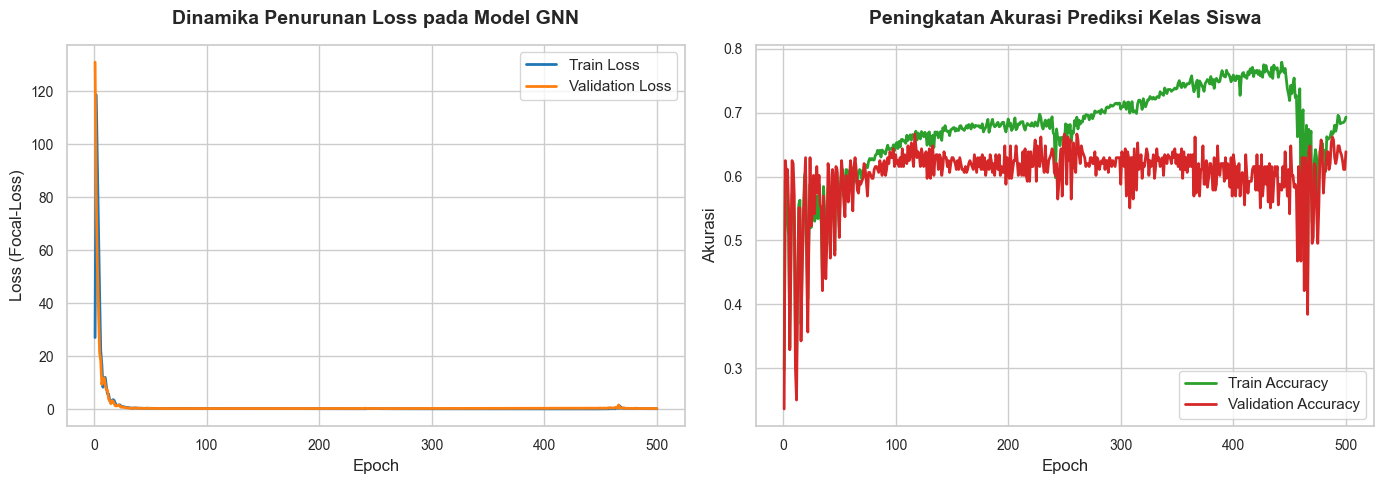

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(history['epoch'], history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Dinamika Penurunan Loss pada Model GNN', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Focal-Loss)', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)


ax2.plot(history['epoch'], history['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history['epoch'], history['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.set_title('Peningkatan Akurasi Prediksi Kelas Siswa', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Akurasi', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_acc, test_pred, test_true = evaluate(data['siswa'].test_mask)

print("="*50)
print(f"FINAL TEST ACCURACY: {test_acc:.4f}")
print("="*50)

y_true = test_true.cpu().numpy()
y_pred = test_pred.cpu().numpy()

nama_kelas = ['Rendah', 'Cukup', 'Tinggi']
print("\nCLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=nama_kelas))

FINAL TEST ACCURACY: 0.5741

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Rendah       0.36      0.15      0.21        59
       Cukup       0.59      0.84      0.70       122
      Tinggi       0.71      0.34      0.46        35

    accuracy                           0.57       216
   macro avg       0.55      0.45      0.46       216
weighted avg       0.55      0.57      0.53       216



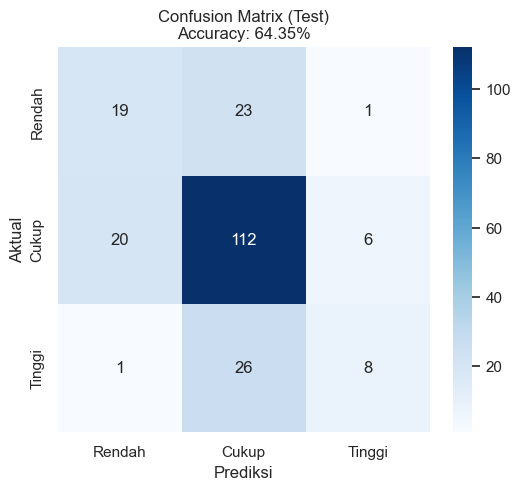

In [ ]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nama_kelas,
    yticklabels=nama_kelas
)

plt.title(f'Confusion Matrix (Test)\nAccuracy: {test_acc*100:.2f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

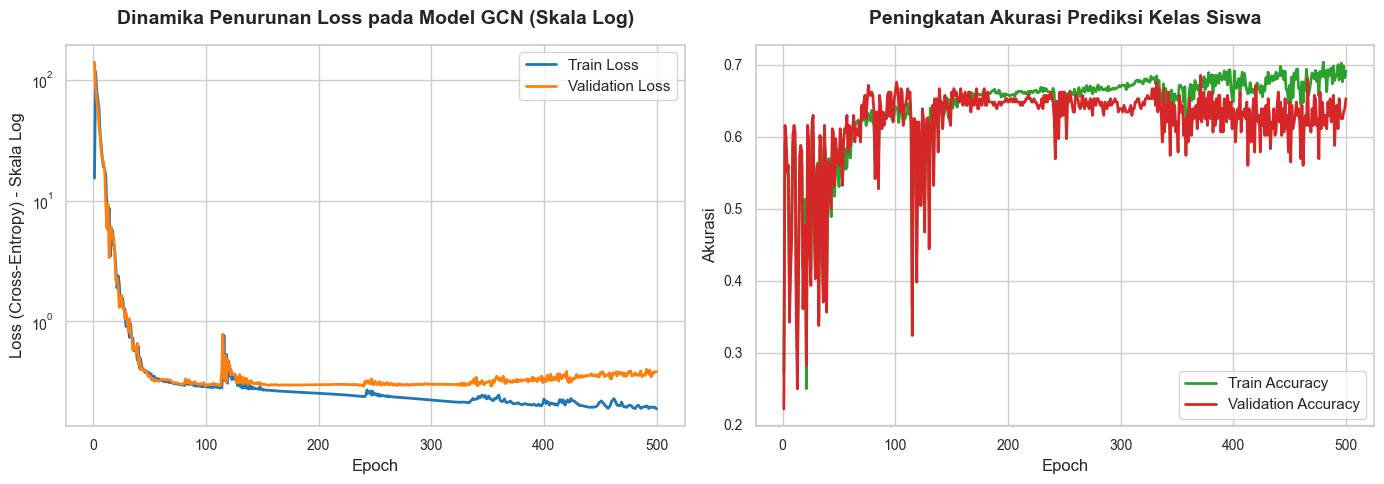

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(history['epoch'], history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_yscale('log')  
ax1.set_title('Dinamika Penurunan Loss pada Model GCN (Skala Log)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Cross-Entropy) - Skala Log', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

ax2.plot(history['epoch'], history['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history['epoch'], history['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.set_title('Peningkatan Akurasi Prediksi Kelas Siswa', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Akurasi', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('gcn_training_history_log.png', dpi=300)

# SHAP

In [ ]:
data.metadata()

(['siswa', 'sekolah', 'wilayah', 'profil_ortu'],
 [('siswa', 'belajar_di', 'sekolah'),
  ('sekolah', 'berlokasi_di', 'wilayah'),
  ('siswa', 'memiliki', 'profil_ortu'),
  ('sekolah', 'rev_belajar_di', 'siswa'),
  ('wilayah', 'rev_berlokasi_di', 'sekolah'),
  ('profil_ortu', 'rev_memiliki', 'siswa')])

In [ ]:

for i, nama_kolom in enumerate(kolom_wilayah):
    print(f"Index {i}: {nama_kolom}")

Index 0: daerah_khusus_Tidak
Index 1: daerah_khusus_Ya
Index 2: jenis_wilayah_KABUPATEN
Index 3: jenis_wilayah_KOTA
Index 4: status_wilayah_RURAL
Index 5: status_wilayah_URBAN


SHAPP REALLL

=== DISTRIBUSI SAMPEL FINAL UNTUK SHAP ===
Total stok anak RURAL asli di Test Set : 112
Total stok anak URBAN asli di Test Set : 104
-> Jumlah yang akhirnya diproses (aman) : 30 per wilayah

--- Memulai Perhitungan SHAP RURAL ---


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Selesai menghitung 30 / 30 siswa...


c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\1088045935.py:200: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



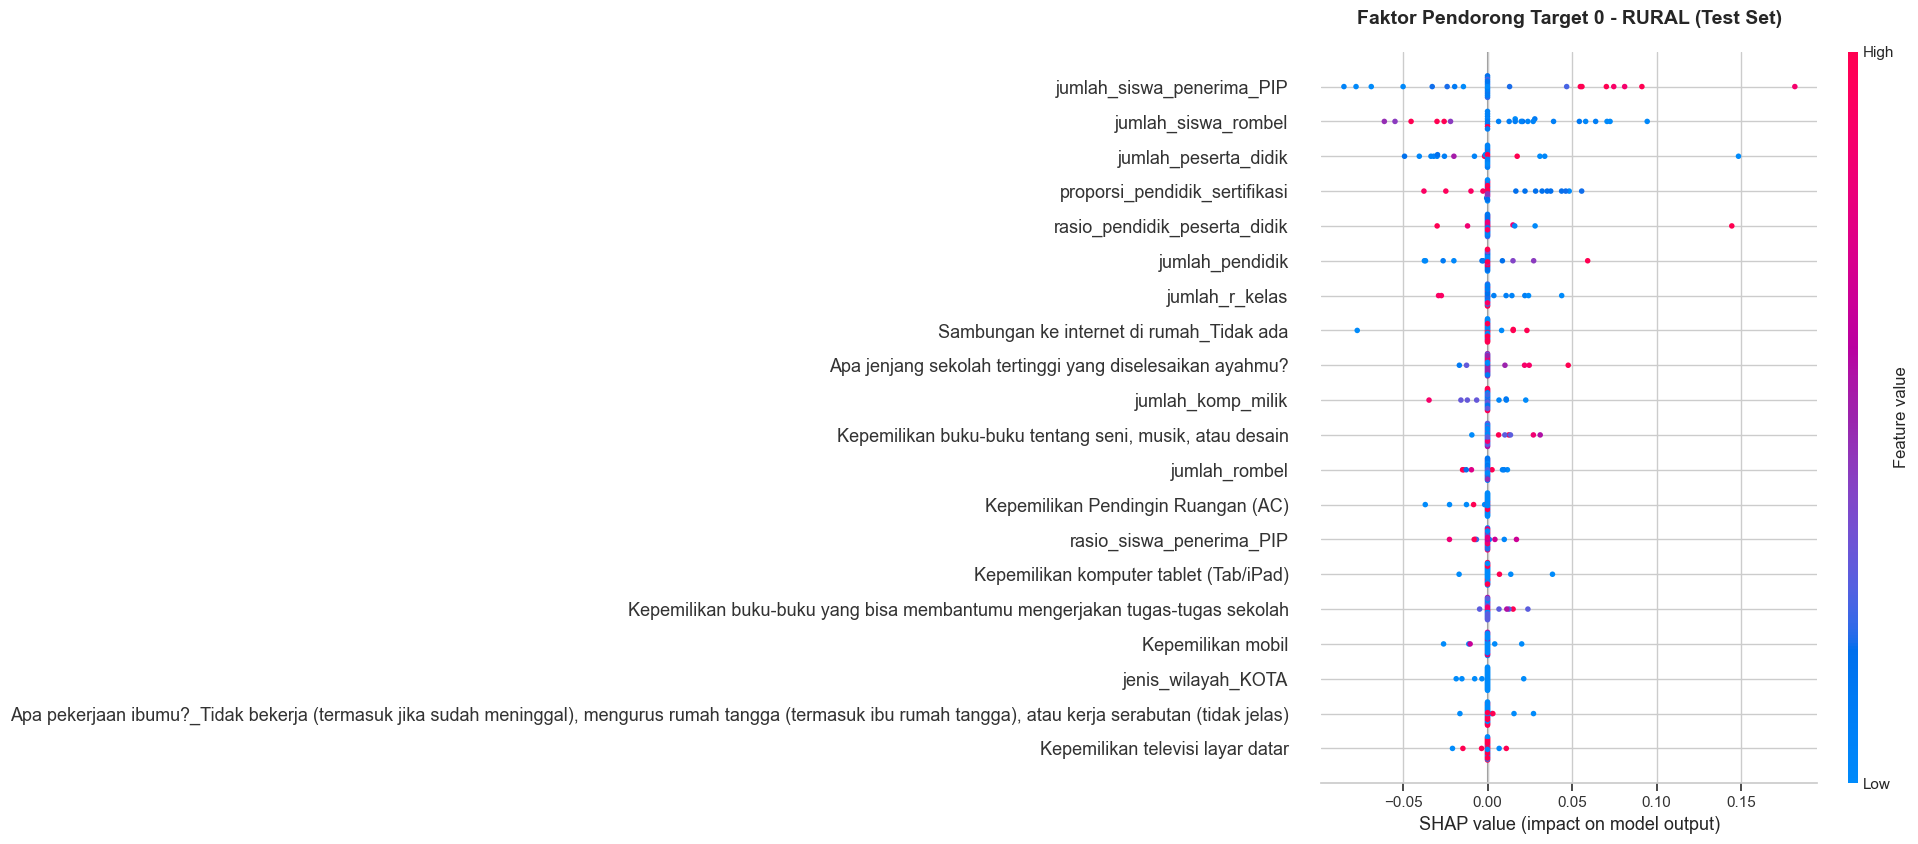

c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\1088045935.py:206: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



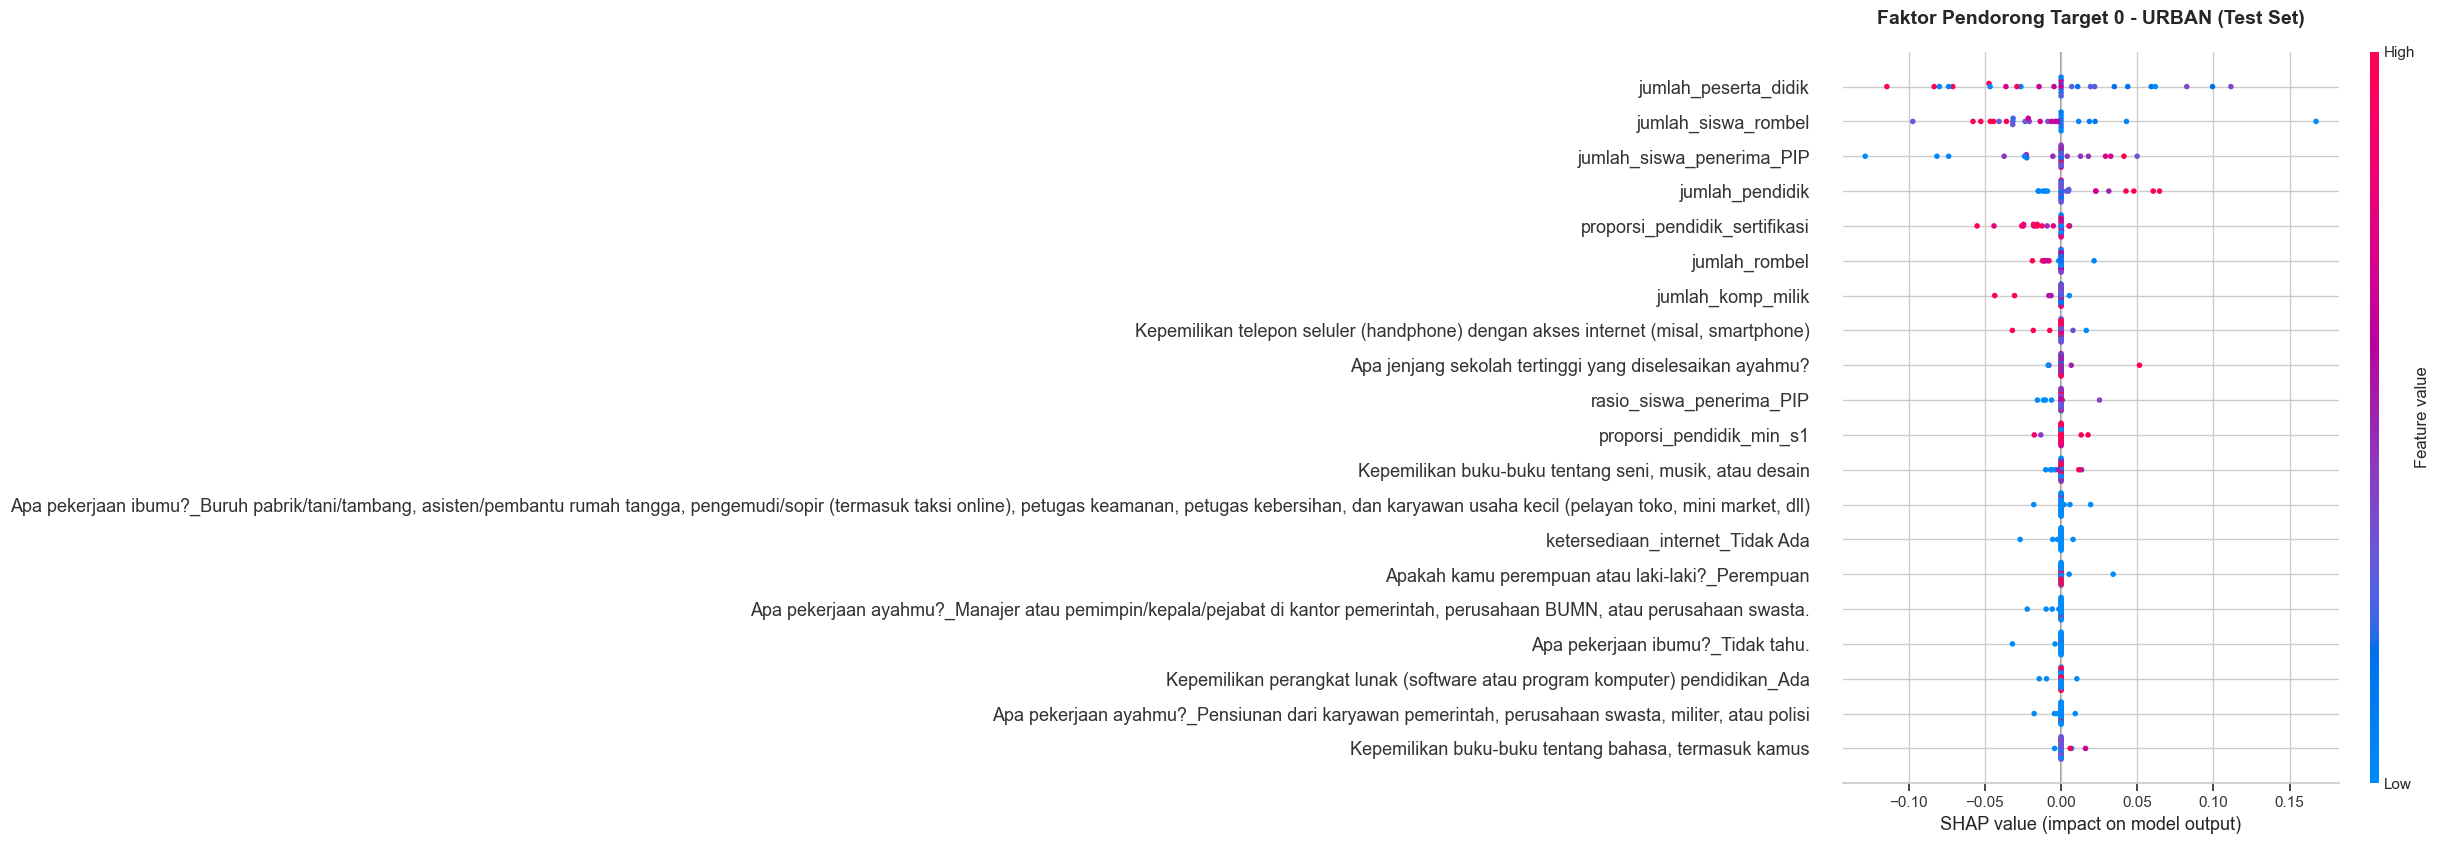

In [ ]:
import numpy as np
import torch
import shap
import random
import matplotlib.pyplot as plt


device = next(model.parameters()).device
model.eval()

X_siswa_orig   = data['siswa'].x.clone().to(device)
X_sekolah_orig = data['sekolah'].x.clone().to(device)
X_ortu_orig    = data['profil_ortu'].x.clone().to(device)
X_wilayah_orig = data['wilayah'].x.clone().to(device)

F_SISWA   = data['siswa'].x.size(1)
F_SEKOLAH = data['sekolah'].x.size(1)
F_ORTU    = data['profil_ortu'].x.size(1)
F_WILAYAH = data['wilayah'].x.size(1)
F_TOTAL   = F_SISWA + F_SEKOLAH + F_ORTU + F_WILAYAH

all_feature_names = kolom_siswa + kolom_sekolah + kolom_ortu + kolom_wilayah


def pick_first_neighbor(dst_list):
    return int(dst_list[0]) if len(dst_list) > 0 else None

def get_neighbors_for_siswa(data, siswa_idx: int):
    e_siswa_sekolah = data['siswa', 'belajar_di', 'sekolah'].edge_index
    e_siswa_ortu    = data['siswa', 'memiliki', 'profil_ortu'].edge_index

    sekolah_dst = e_siswa_sekolah[1, e_siswa_sekolah[0] == siswa_idx].tolist()
    ortu_dst    = e_siswa_ortu[1,    e_siswa_ortu[0]    == siswa_idx].tolist()

    sekolah_idx = pick_first_neighbor(sekolah_dst)
    ortu_idx    = pick_first_neighbor(ortu_dst)

    wilayah_idx = None
    if sekolah_idx is not None:
        e_sekolah_wilayah = data['sekolah', 'berlokasi_di', 'wilayah'].edge_index
        wilayah_dst = e_sekolah_wilayah[1, e_sekolah_wilayah[0] == sekolah_idx].tolist()
        wilayah_idx = pick_first_neighbor(wilayah_dst)

    return sekolah_idx, ortu_idx, wilayah_idx


def predict_targetclass_for_one_siswa_from_concat(X_concat_np, siswa_idx, sekolah_idx, ortu_idx, wilayah_idx, target_class):
    X_concat = torch.tensor(X_concat_np, dtype=torch.float, device=device)
    outs = []
    
    idx_1 = F_SISWA
    idx_2 = idx_1 + F_SEKOLAH
    idx_3 = idx_2 + F_ORTU
    idx_4 = idx_3 + F_WILAYAH

    for i in range(X_concat.size(0)):
        xs = X_concat[i, 0:idx_1]
        xk = X_concat[i, idx_1:idx_2]
        xo = X_concat[i, idx_2:idx_3]
        xw = X_concat[i, idx_3:idx_4]

        data['siswa'].x = X_siswa_orig.clone()
        data['sekolah'].x = X_sekolah_orig.clone()
        data['profil_ortu'].x = X_ortu_orig.clone()
        data['wilayah'].x = X_wilayah_orig.clone()

        data['siswa'].x[siswa_idx] = xs
        data['sekolah'].x[sekolah_idx] = xk
        data['profil_ortu'].x[ortu_idx] = xo
        data['wilayah'].x[wilayah_idx] = xw

        with torch.no_grad():
            out_dict = model(data.x_dict, data.edge_index_dict)
            logits = out_dict['siswa'][siswa_idx]
            proba = logits.softmax(dim=-1)[target_class]

        outs.append(float(proba.detach().cpu()))
        
    data['siswa'].x = X_siswa_orig.clone()
    data['sekolah'].x = X_sekolah_orig.clone()
    data['profil_ortu'].x = X_ortu_orig.clone()
    data['wilayah'].x = X_wilayah_orig.clone()

    return np.array(outs)


def build_background(data, n=100, seed=42):
    rng = random.Random(seed)
    idxs = [rng.randrange(data['siswa'].num_nodes) for _ in range(n)]
    rows = []
    for si in idxs:
        sk, ot, wil = get_neighbors_for_siswa(data, si)
        if sk is None or ot is None or wil is None:
            continue
            
        row = torch.cat([
            data['siswa'].x[si].cpu(),
            data['sekolah'].x[sk].cpu(),
            data['profil_ortu'].x[ot].cpu(),
            data['wilayah'].x[wil].cpu()
        ], dim=0).numpy()
        rows.append(row)
    return np.stack(rows, axis=0)

background = build_background(data, n=100) 

rural_test_asli = []
urban_test_asli = []
test_indices = data['siswa'].test_mask.nonzero(as_tuple=True)[0].tolist()


INDEKS_RURAL = 4

for si in test_indices:
    sk, ot, wil = get_neighbors_for_siswa(data, si)
    if sk is None or ot is None or wil is None:
        continue
        
    is_rural = data['wilayah'].x[wil, INDEKS_RURAL].item() == 1.0 
    
    if is_rural:
        rural_test_asli.append(si)
    else:
        urban_test_asli.append(si)

random.seed(42) 


BATAS_SAMPEL = 30
jumlah_sampel_aman = min(BATAS_SAMPEL, len(rural_test_asli), len(urban_test_asli))

urban_siswa_idxs = random.sample(urban_test_asli, jumlah_sampel_aman)
rural_siswa_idxs = random.sample(rural_test_asli, jumlah_sampel_aman)

print("=== DISTRIBUSI SAMPEL FINAL UNTUK SHAP ===")
print(f"Total stok anak RURAL asli di Test Set : {len(rural_test_asli)}")
print(f"Total stok anak URBAN asli di Test Set : {len(urban_test_asli)}")
print(f"-> Jumlah yang akhirnya diproses (aman) : {len(rural_siswa_idxs)} per wilayah")

TARGET_CLASS = 0


def calculate_shap_for_cohort(siswa_idxs, background, target_class):
    cohort_shap_values = []
    cohort_features = []
    
    for idx, si in enumerate(siswa_idxs):
        sk, ot, wil = get_neighbors_for_siswa(data, si)
        if sk is None or ot is None or wil is None:
            continue
        
        x_concat = torch.cat([
            data['siswa'].x[si].cpu(),
            data['sekolah'].x[sk].cpu(),
            data['profil_ortu'].x[ot].cpu(),   
            data['wilayah'].x[wil].cpu()     
        ], dim=0).numpy().reshape(1, -1)
        
        def predict_fn(X):
            return predict_targetclass_for_one_siswa_from_concat(X, si, sk, ot, wil, target_class)
        
        explainer = shap.KernelExplainer(predict_fn, background)
        shap_val = explainer.shap_values(x_concat, nsamples=100)
        
        if isinstance(shap_val, list):
            cohort_shap_values.append(shap_val[0][0])
        else:
            cohort_shap_values.append(shap_val[0])
            
        cohort_features.append(x_concat[0])
        
        if (idx + 1) % 10 == 0:
            print(f"Selesai menghitung {idx + 1} / {len(siswa_idxs)} siswa...")
            
    return np.array(cohort_shap_values), np.array(cohort_features)

print("\n--- Memulai Perhitungan SHAP RURAL ---")
shap_rural, X_rural_np = calculate_shap_for_cohort(rural_siswa_idxs, background, TARGET_CLASS)

print("\n--- Memulai Perhitungan SHAP URBAN ---")
shap_urban, X_urban_np = calculate_shap_for_cohort(urban_siswa_idxs, background, TARGET_CLASS)


plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - RURAL (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_rural, X_rural_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - URBAN (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_urban, X_urban_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

print(f"\n--- Menyimpan Hasil untuk Target Class {TARGET_CLASS} ke CSV ---")

df_shap_rural = pd.DataFrame(shap_rural, columns=all_feature_names)
nama_file_rural = f"hasil_shap_rural_class_{TARGET_CLASS}.csv"
df_shap_rural.to_csv(nama_file_rural, index=False)
print(f"Berhasil menyimpan: {nama_file_rural}")


df_shap_urban = pd.DataFrame(shap_urban, columns=all_feature_names)
nama_file_urban = f"hasil_shap_urban_class_{TARGET_CLASS}.csv"
df_shap_urban.to_csv(nama_file_urban, index=False)
print(f"Berhasil menyimpan: {nama_file_urban}")


df_fitur_rural = pd.DataFrame(X_rural_np, columns=all_feature_names)
df_fitur_rural.to_csv(f"fitur_asli_rural_class_{TARGET_CLASS}.csv", index=False)

df_fitur_urban = pd.DataFrame(X_urban_np, columns=all_feature_names)
df_fitur_urban.to_csv(f"fitur_asli_urban_class_{TARGET_CLASS}.csv", index=False)
print("Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.")


--- Menyimpan Hasil untuk Target Class 0 ke CSV ---
Berhasil menyimpan: hasil_shap_rural_class_0.csv
Berhasil menyimpan: hasil_shap_urban_class_0.csv
Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.



--- Memulai Perhitungan SHAP RURAL ---


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Selesai menghitung 30 / 30 siswa...


c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\602081305.py:52: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



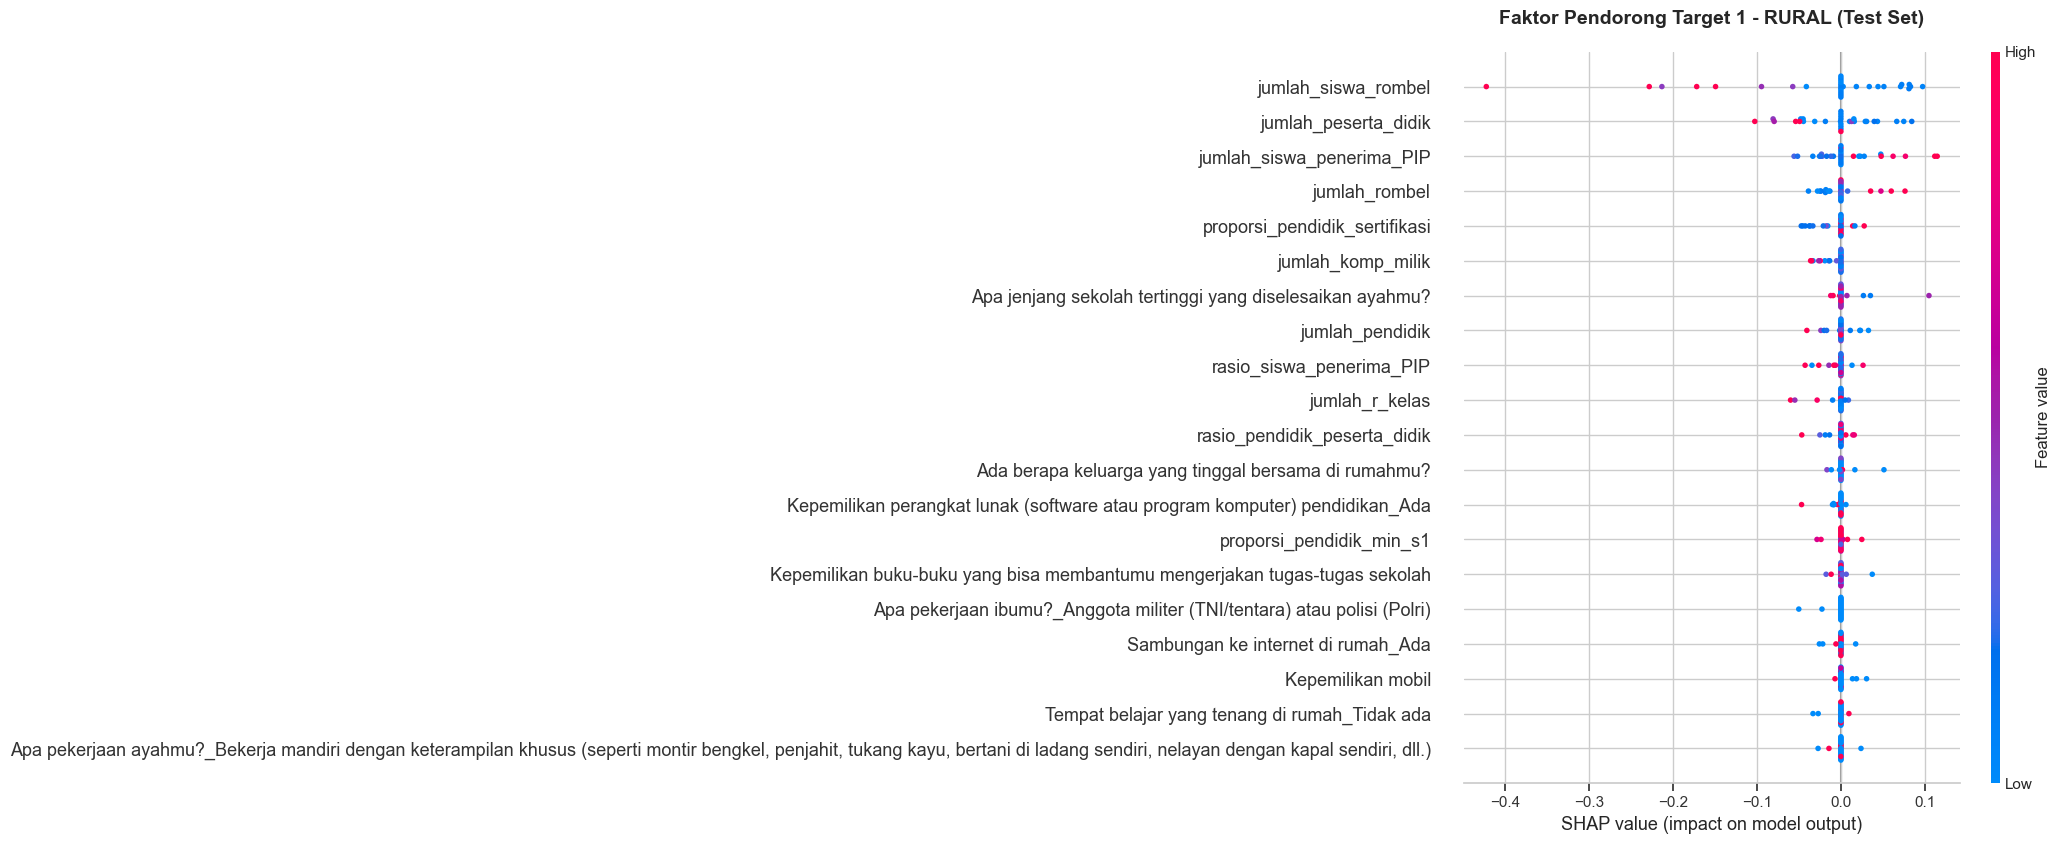

c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\602081305.py:58: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



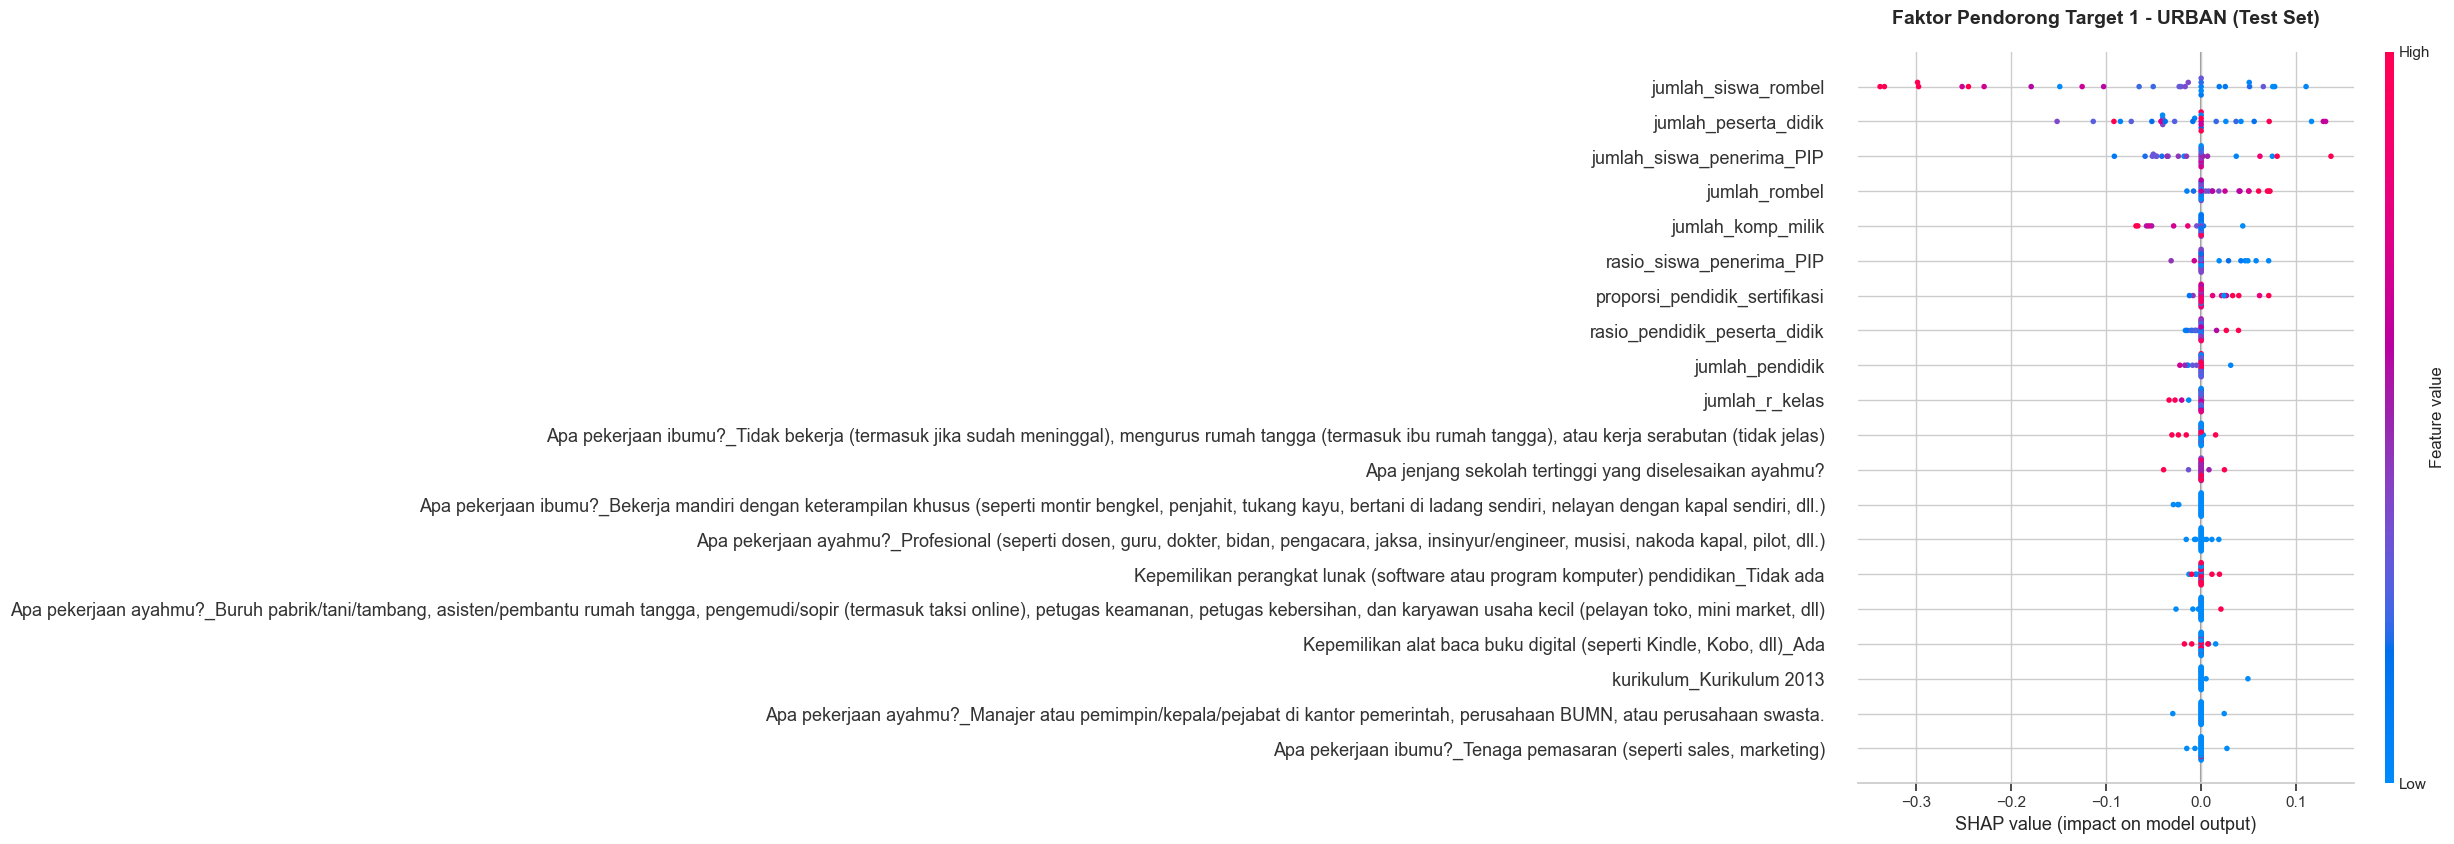

In [ ]:
TARGET_CLASS = 1


def calculate_shap_for_cohort(siswa_idxs, background, target_class):
    cohort_shap_values = []
    cohort_features = []
    
    for idx, si in enumerate(siswa_idxs):
        sk, ot, wil = get_neighbors_for_siswa(data, si)
        if sk is None or ot is None or wil is None:
            continue
        
        x_concat = torch.cat([
            data['siswa'].x[si].cpu(),
            data['sekolah'].x[sk].cpu(),
            data['profil_ortu'].x[ot].cpu(),   
            data['wilayah'].x[wil].cpu()     
        ], dim=0).numpy().reshape(1, -1)
        
        def predict_fn(X):
            return predict_targetclass_for_one_siswa_from_concat(X, si, sk, ot, wil, target_class)
        
        explainer = shap.KernelExplainer(predict_fn, background)
        shap_val = explainer.shap_values(x_concat, nsamples=100)
        
        if isinstance(shap_val, list):
            cohort_shap_values.append(shap_val[0][0])
        else:
            cohort_shap_values.append(shap_val[0])
            
        cohort_features.append(x_concat[0])
        
        if (idx + 1) % 10 == 0:
            print(f"Selesai menghitung {idx + 1} / {len(siswa_idxs)} siswa...")
            
    return np.array(cohort_shap_values), np.array(cohort_features)

print("\n--- Memulai Perhitungan SHAP RURAL ---")
shap_rural, X_rural_np = calculate_shap_for_cohort(rural_siswa_idxs, background, TARGET_CLASS)

print("\n--- Memulai Perhitungan SHAP URBAN ---")
shap_urban, X_urban_np = calculate_shap_for_cohort(urban_siswa_idxs, background, TARGET_CLASS)


plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - RURAL (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_rural, X_rural_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - URBAN (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_urban, X_urban_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd


print(f"\n--- Menyimpan Hasil untuk Target Class {TARGET_CLASS} ke CSV ---")


df_shap_rural = pd.DataFrame(shap_rural, columns=all_feature_names)
nama_file_rural = f"hasil_shap_rural_class_{TARGET_CLASS}.csv"
df_shap_rural.to_csv(nama_file_rural, index=False)
print(f"Berhasil menyimpan: {nama_file_rural}")


df_shap_urban = pd.DataFrame(shap_urban, columns=all_feature_names)
nama_file_urban = f"hasil_shap_urban_class_{TARGET_CLASS}.csv"
df_shap_urban.to_csv(nama_file_urban, index=False)
print(f"Berhasil menyimpan: {nama_file_urban}")


df_fitur_rural = pd.DataFrame(X_rural_np, columns=all_feature_names)
df_fitur_rural.to_csv(f"fitur_asli_rural_class_{TARGET_CLASS}.csv", index=False)

df_fitur_urban = pd.DataFrame(X_urban_np, columns=all_feature_names)
df_fitur_urban.to_csv(f"fitur_asli_urban_class_{TARGET_CLASS}.csv", index=False)
print("Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.")


--- Menyimpan Hasil untuk Target Class 1 ke CSV ---
Berhasil menyimpan: hasil_shap_rural_class_1.csv
Berhasil menyimpan: hasil_shap_urban_class_1.csv
Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.



--- Memulai Perhitungan SHAP RURAL ---


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Selesai menghitung 30 / 30 siswa...


c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\1666465755.py:52: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



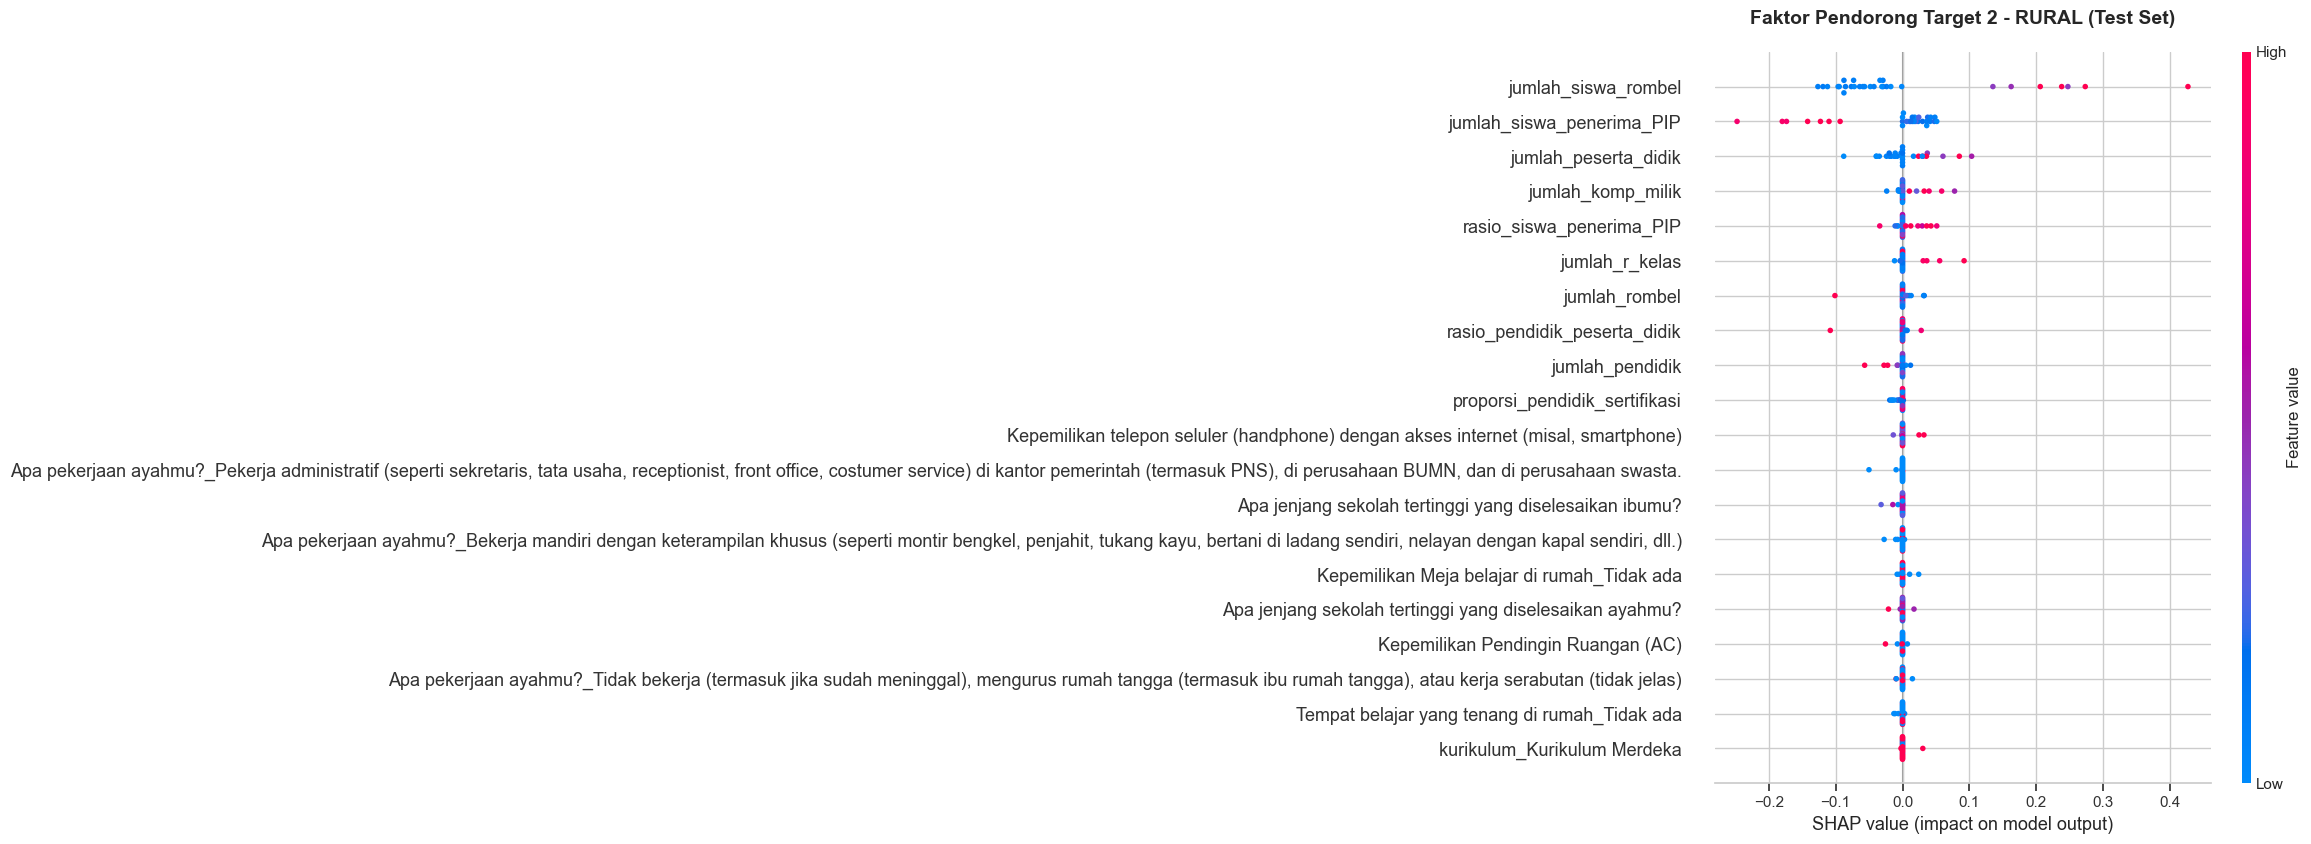

c:\python\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\Michael Luwi Pallea\AppData\Local\Temp\ipykernel_5896\1666465755.py:58: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



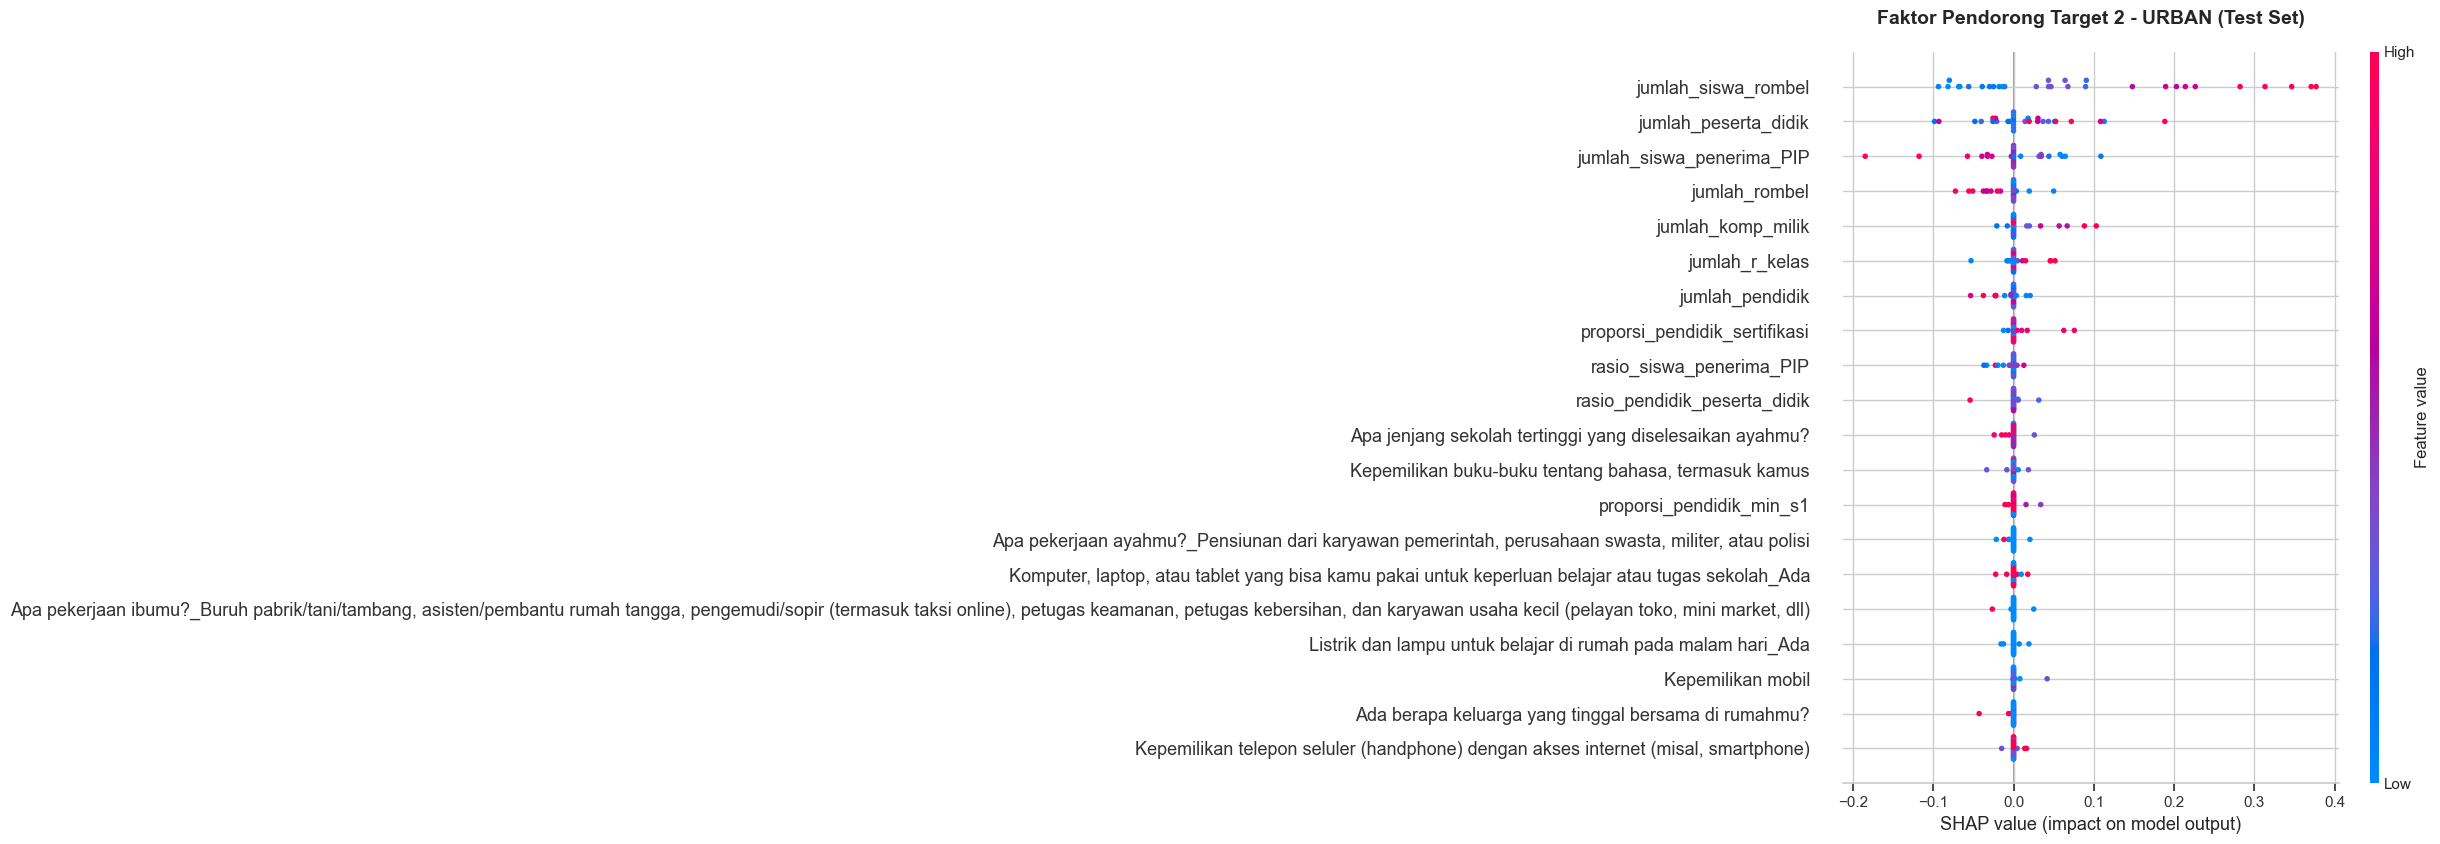

In [ ]:
TARGET_CLASS = 2

def calculate_shap_for_cohort(siswa_idxs, background, target_class):
    cohort_shap_values = []
    cohort_features = []
    
    for idx, si in enumerate(siswa_idxs):
        sk, ot, wil = get_neighbors_for_siswa(data, si)
        if sk is None or ot is None or wil is None:
            continue
        
        x_concat = torch.cat([
            data['siswa'].x[si].cpu(),
            data['sekolah'].x[sk].cpu(),
            data['profil_ortu'].x[ot].cpu(),   
            data['wilayah'].x[wil].cpu()     
        ], dim=0).numpy().reshape(1, -1)
        
        def predict_fn(X):
            return predict_targetclass_for_one_siswa_from_concat(X, si, sk, ot, wil, target_class)
        
        explainer = shap.KernelExplainer(predict_fn, background)
        shap_val = explainer.shap_values(x_concat, nsamples=100)
        
        if isinstance(shap_val, list):
            cohort_shap_values.append(shap_val[0][0])
        else:
            cohort_shap_values.append(shap_val[0])
            
        cohort_features.append(x_concat[0])
        
        if (idx + 1) % 10 == 0:
            print(f"Selesai menghitung {idx + 1} / {len(siswa_idxs)} siswa...")
            
    return np.array(cohort_shap_values), np.array(cohort_features)

print("\n--- Memulai Perhitungan SHAP RURAL ---")
shap_rural, X_rural_np = calculate_shap_for_cohort(rural_siswa_idxs, background, TARGET_CLASS)

print("\n--- Memulai Perhitungan SHAP URBAN ---")
shap_urban, X_urban_np = calculate_shap_for_cohort(urban_siswa_idxs, background, TARGET_CLASS)

plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - RURAL (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_rural, X_rural_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Faktor Pendorong Target {TARGET_CLASS} - URBAN (Test Set)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_urban, X_urban_np, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd


print(f"\n--- Menyimpan Hasil untuk Target Class {TARGET_CLASS} ke CSV ---")

df_shap_rural = pd.DataFrame(shap_rural, columns=all_feature_names)
nama_file_rural = f"hasil_shap_rural_class_{TARGET_CLASS}.csv"
df_shap_rural.to_csv(nama_file_rural, index=False)
print(f"Berhasil menyimpan: {nama_file_rural}")

df_shap_urban = pd.DataFrame(shap_urban, columns=all_feature_names)
nama_file_urban = f"hasil_shap_urban_class_{TARGET_CLASS}.csv"
df_shap_urban.to_csv(nama_file_urban, index=False)
print(f"Berhasil menyimpan: {nama_file_urban}")


df_fitur_rural = pd.DataFrame(X_rural_np, columns=all_feature_names)
df_fitur_rural.to_csv(f"fitur_asli_rural_class_{TARGET_CLASS}.csv", index=False)

df_fitur_urban = pd.DataFrame(X_urban_np, columns=all_feature_names)
df_fitur_urban.to_csv(f"fitur_asli_urban_class_{TARGET_CLASS}.csv", index=False)
print("Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.")


--- Menyimpan Hasil untuk Target Class 2 ke CSV ---
Berhasil menyimpan: hasil_shap_rural_class_2.csv
Berhasil menyimpan: hasil_shap_urban_class_2.csv
Berhasil menyimpan data fitur asli untuk kedua wilayah secara spesifik.
